In [1]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

In [2]:
# %%
# Cargar datos
data_path = Path('../extraccion_métricas/csv_explicabilidad/subgrafos/metricas_usuario_3')

df_caminos = pd.read_csv(data_path / 'metricas_caminos.csv')
df_globales = pd.read_csv(data_path / 'metricas_globales.csv')
df_ejemplos = pd.read_csv(data_path / 'metricas_nivel_ejemplo.csv')
df_propiedad = pd.read_csv(data_path / 'metricas_nivel_propiedad.csv')

print("✓ Datos cargados correctamente")
print(f"  - Caminos: {len(df_caminos)} filas")
print(f"  - Globales: {len(df_globales)} filas")
print(f"  - Ejemplos: {len(df_ejemplos)} filas")
print(f"  - Propiedades: {len(df_propiedad)} filas")

✓ Datos cargados correctamente
  - Caminos: 703 filas
  - Globales: 50 filas
  - Ejemplos: 200 filas
  - Propiedades: 992 filas


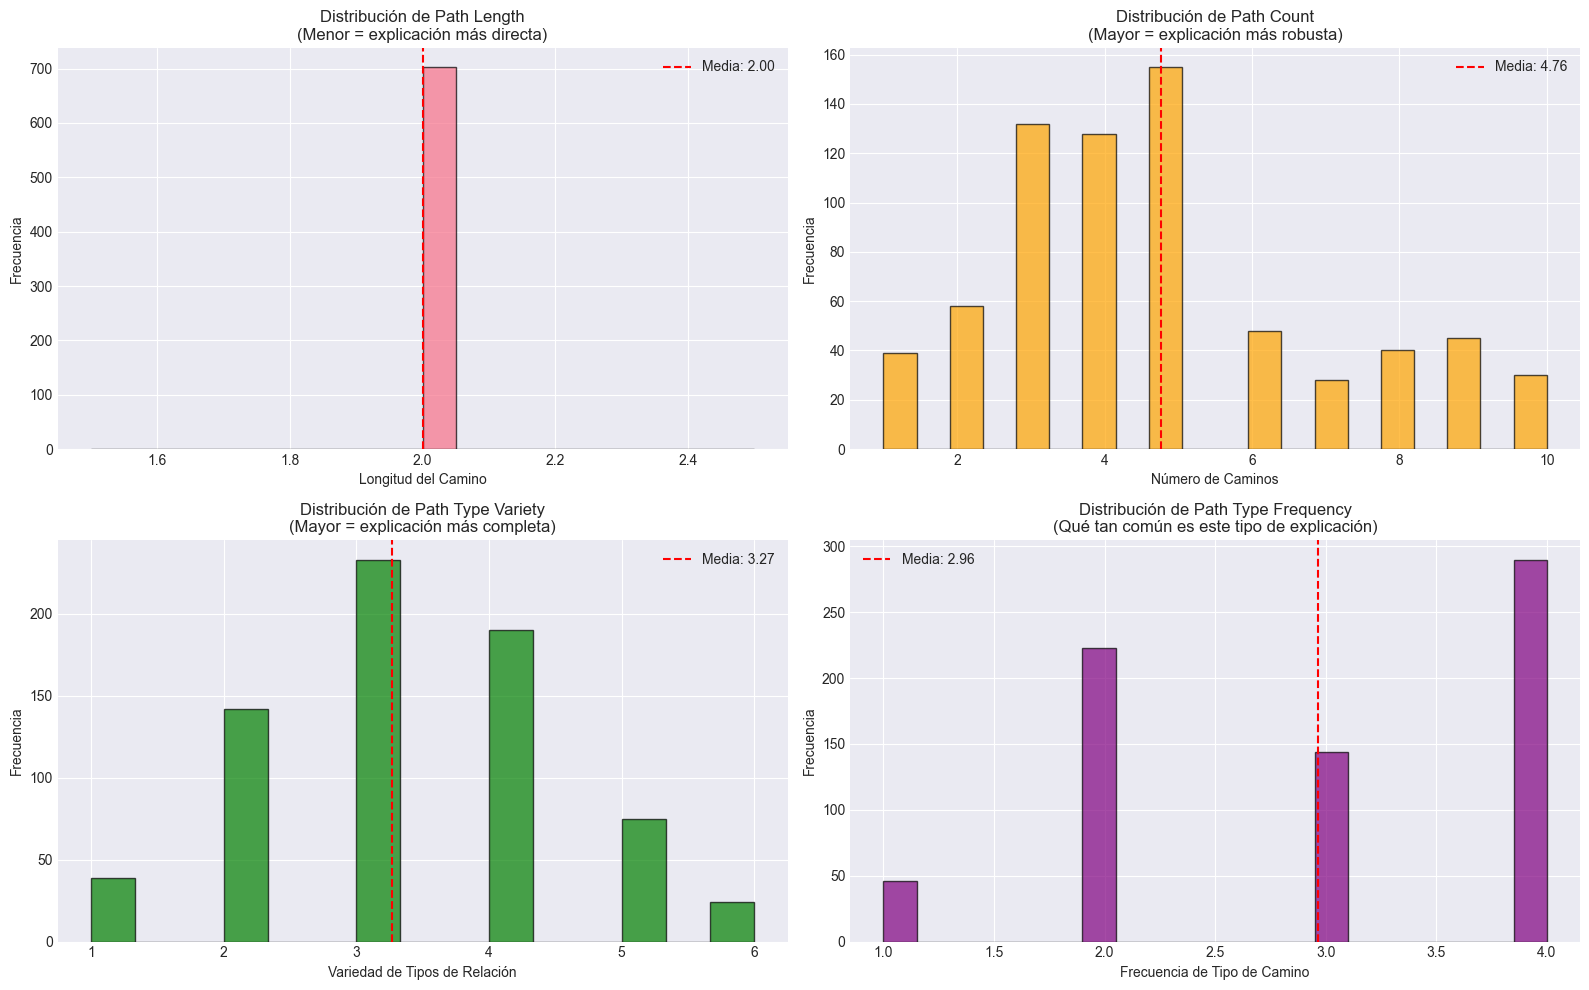

In [3]:
# ## 1. ANÁLISIS DE MÉTRICAS DE CAMINOS (703 filas)
# 
# Analizan la estructura de conexiones entre hoteles consumidos y recomendados

# %%
# 1.1 Distribución de longitud de caminos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Path Length
axes[0, 0].hist(df_caminos['path_length'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Longitud del Camino')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Path Length\n(Menor = explicación más directa)')
axes[0, 0].axvline(df_caminos['path_length'].mean(), color='red', linestyle='--', 
                    label=f'Media: {df_caminos["path_length"].mean():.2f}')
axes[0, 0].legend()

# Path Count
axes[0, 1].hist(df_caminos['path_count'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Número de Caminos')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Path Count\n(Mayor = explicación más robusta)')
axes[0, 1].axvline(df_caminos['path_count'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_caminos["path_count"].mean():.2f}')
axes[0, 1].legend()

# Path Type Variety
axes[1, 0].hist(df_caminos['path_type_variety'], bins=15, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Variedad de Tipos de Relación')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Path Type Variety\n(Mayor = explicación más completa)')
axes[1, 0].axvline(df_caminos['path_type_variety'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_caminos["path_type_variety"].mean():.2f}')
axes[1, 0].legend()

# Path Type Frequency
axes[1, 1].hist(df_caminos['path_type_frequency'], bins=20, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Frecuencia de Tipo de Camino')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Path Type Frequency\n(Qué tan común es este tipo de explicación)')
axes[1, 1].axvline(df_caminos['path_type_frequency'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_caminos["path_type_frequency"].mean():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('01_distribucion_metricas_caminos.png', dpi=300, bbox_inches='tight')
plt.show()


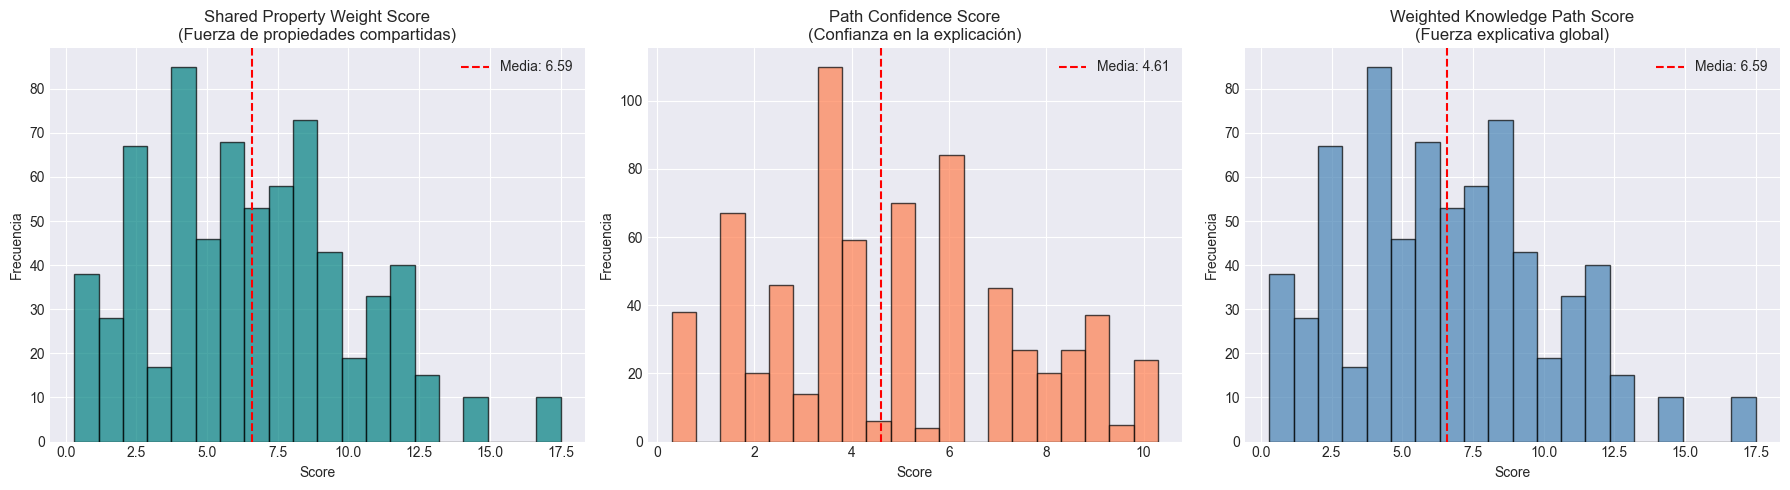

In [4]:
# %%
# 1.2 Análisis de scores ponderados
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Shared Property Weight Score
axes[0].hist(df_caminos['shared_property_weight_score'], bins=20, 
             edgecolor='black', alpha=0.7, color='teal')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Shared Property Weight Score\n(Fuerza de propiedades compartidas)')
axes[0].axvline(df_caminos['shared_property_weight_score'].mean(), 
                color='red', linestyle='--', label=f'Media: {df_caminos["shared_property_weight_score"].mean():.2f}')
axes[0].legend()

# Path Confidence Score
axes[1].hist(df_caminos['path_confidence_score'], bins=20, 
             edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Path Confidence Score\n(Confianza en la explicación)')
axes[1].axvline(df_caminos['path_confidence_score'].mean(), 
                color='red', linestyle='--', label=f'Media: {df_caminos["path_confidence_score"].mean():.2f}')
axes[1].legend()

# Weighted KPS
axes[2].hist(df_caminos['weighted_kps'], bins=20, 
             edgecolor='black', alpha=0.7, color='steelblue')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Weighted Knowledge Path Score\n(Fuerza explicativa global)')
axes[2].axvline(df_caminos['weighted_kps'].mean(), 
                color='red', linestyle='--', label=f'Media: {df_caminos["weighted_kps"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('02_scores_ponderados_caminos.png', dpi=300, bbox_inches='tight')
plt.show()

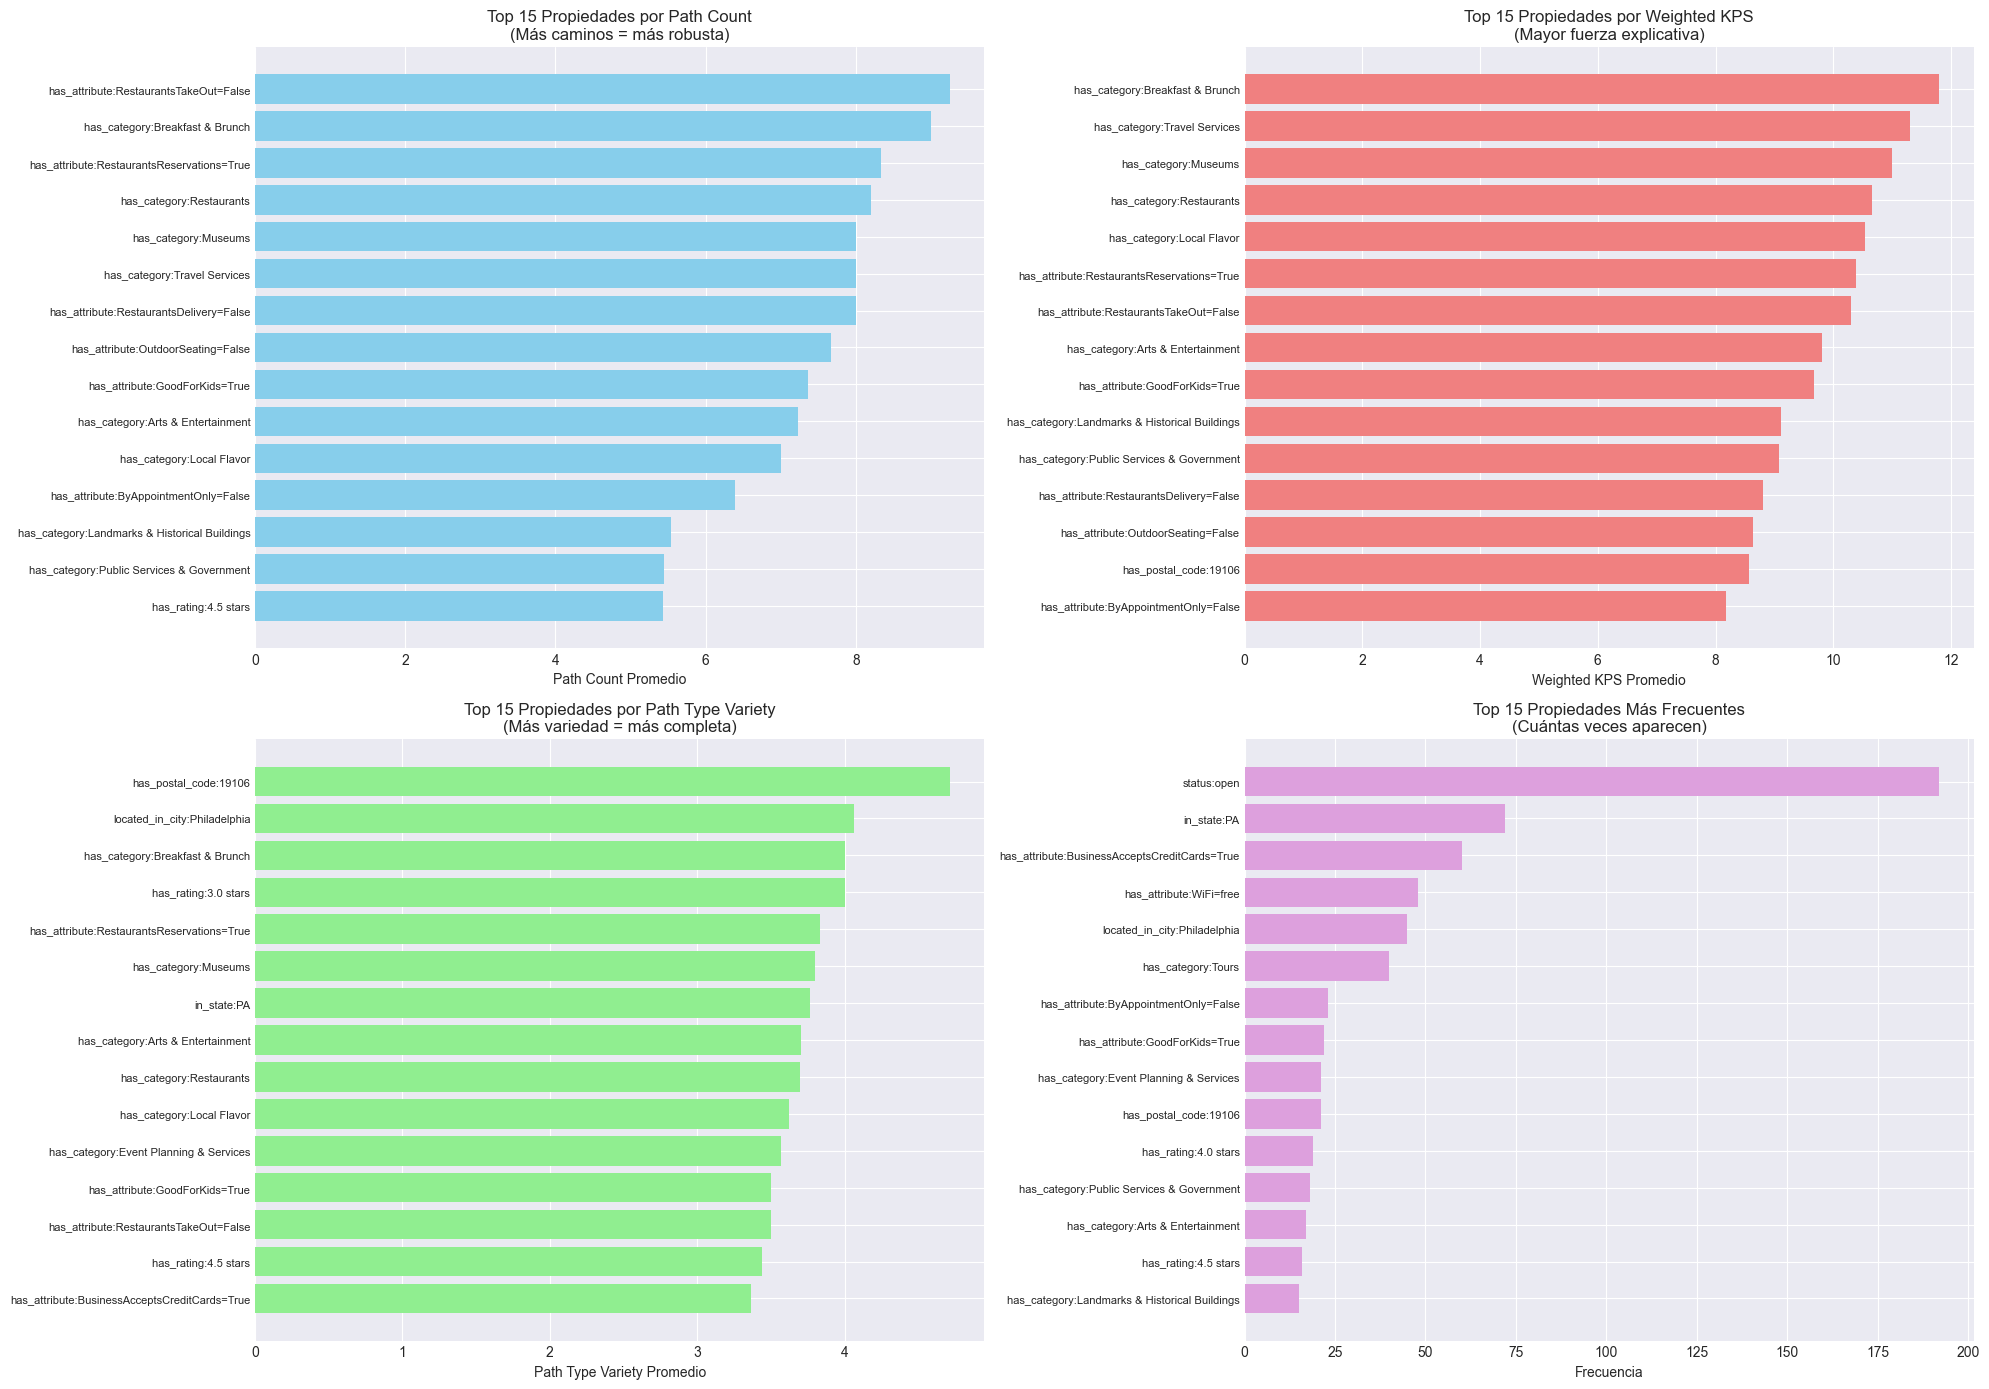

In [26]:
# %%
# 1.3 Top propiedades por métricas de camino (CON VALORES COMPLETOS)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Top propiedades por Path Count
top_path_count = df_caminos.groupby('propiedad')['path_count'].mean().sort_values(ascending=False).head(15)
axes[0, 0].barh(range(len(top_path_count)), top_path_count.values, color='skyblue')
axes[0, 0].set_yticks(range(len(top_path_count)))
# CAMBIO: Mostrar propiedad completa, truncar si es muy larga
axes[0, 0].set_yticklabels([prop[:50] + '...' if len(prop) > 50 else prop 
                             for prop in top_path_count.index], 
                            fontsize=8)
axes[0, 0].set_xlabel('Path Count Promedio')
axes[0, 0].set_title('Top 15 Propiedades por Path Count\n(Más caminos = más robusta)')
axes[0, 0].invert_yaxis()

# Top propiedades por Weighted KPS
top_kps = df_caminos.groupby('propiedad')['weighted_kps'].mean().sort_values(ascending=False).head(15)
axes[0, 1].barh(range(len(top_kps)), top_kps.values, color='lightcoral')
axes[0, 1].set_yticks(range(len(top_kps)))
axes[0, 1].set_yticklabels([prop[:50] + '...' if len(prop) > 50 else prop 
                             for prop in top_kps.index], 
                            fontsize=8)
axes[0, 1].set_xlabel('Weighted KPS Promedio')
axes[0, 1].set_title('Top 15 Propiedades por Weighted KPS\n(Mayor fuerza explicativa)')
axes[0, 1].invert_yaxis()

# Top propiedades por Path Type Variety
top_variety = df_caminos.groupby('propiedad')['path_type_variety'].mean().sort_values(ascending=False).head(15)
axes[1, 0].barh(range(len(top_variety)), top_variety.values, color='lightgreen')
axes[1, 0].set_yticks(range(len(top_variety)))
axes[1, 0].set_yticklabels([prop[:50] + '...' if len(prop) > 50 else prop 
                             for prop in top_variety.index], 
                            fontsize=8)
axes[1, 0].set_xlabel('Path Type Variety Promedio')
axes[1, 0].set_title('Top 15 Propiedades por Path Type Variety\n(Más variedad = más completa)')
axes[1, 0].invert_yaxis()

# Frecuencia de propiedades
prop_counts = df_caminos['propiedad'].value_counts().head(15)
axes[1, 1].barh(range(len(prop_counts)), prop_counts.values, color='plum')
axes[1, 1].set_yticks(range(len(prop_counts)))
axes[1, 1].set_yticklabels([prop[:50] + '...' if len(prop) > 50 else prop 
                             for prop in prop_counts.index], 
                            fontsize=8)
axes[1, 1].set_xlabel('Frecuencia')
axes[1, 1].set_title('Top 15 Propiedades Más Frecuentes\n(Cuántas veces aparecen)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('03_top_propiedades_caminos_COMPLETO.png', dpi=300, bbox_inches='tight')
plt.show()

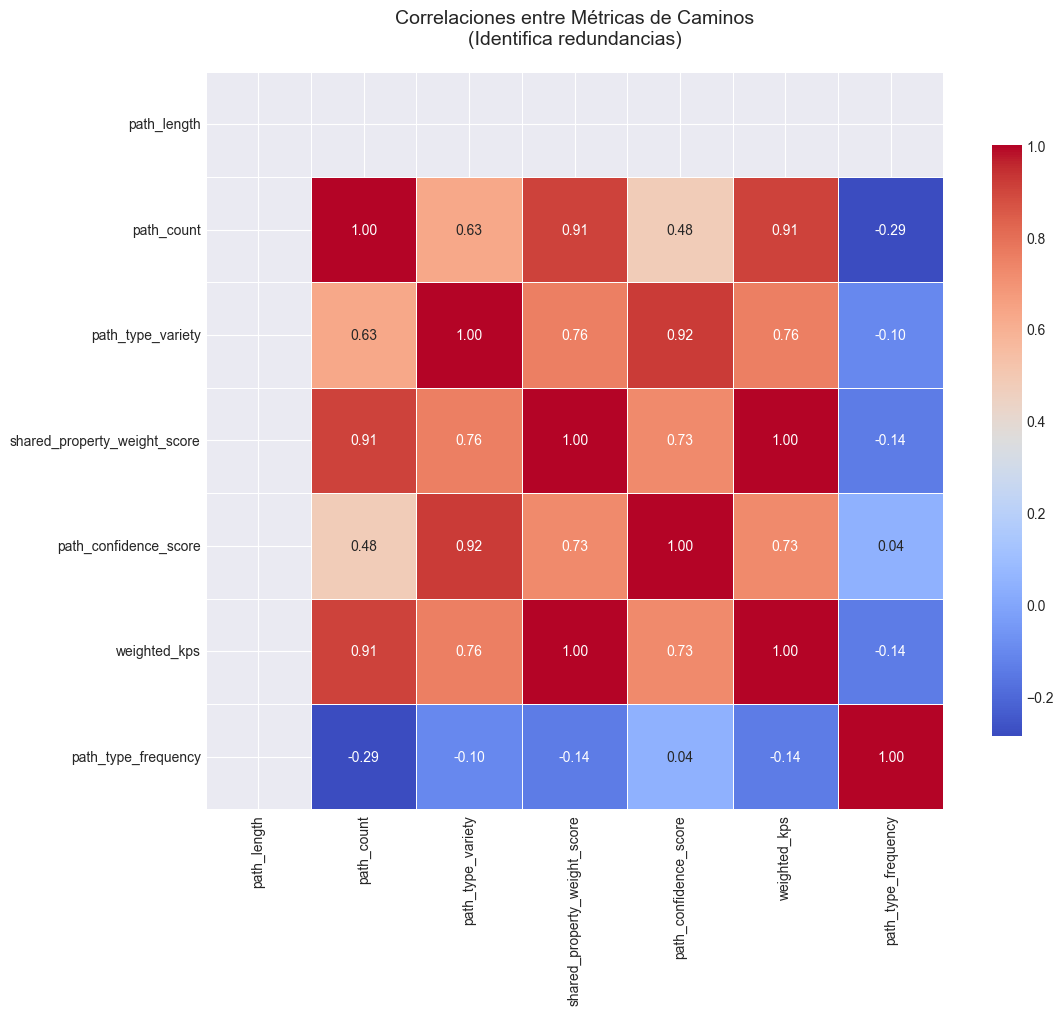

In [6]:
# %%
# 1.4 Heatmap de correlaciones entre métricas de caminos
caminos_numeric = df_caminos[['path_length', 'path_count', 'path_type_variety', 
                               'shared_property_weight_score', 'path_confidence_score', 
                               'weighted_kps', 'path_type_frequency']]

plt.figure(figsize=(12, 10))
corr_matrix = caminos_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlaciones entre Métricas de Caminos\n(Identifica redundancias)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('04_correlaciones_caminos.png', dpi=300, bbox_inches='tight')
plt.show()

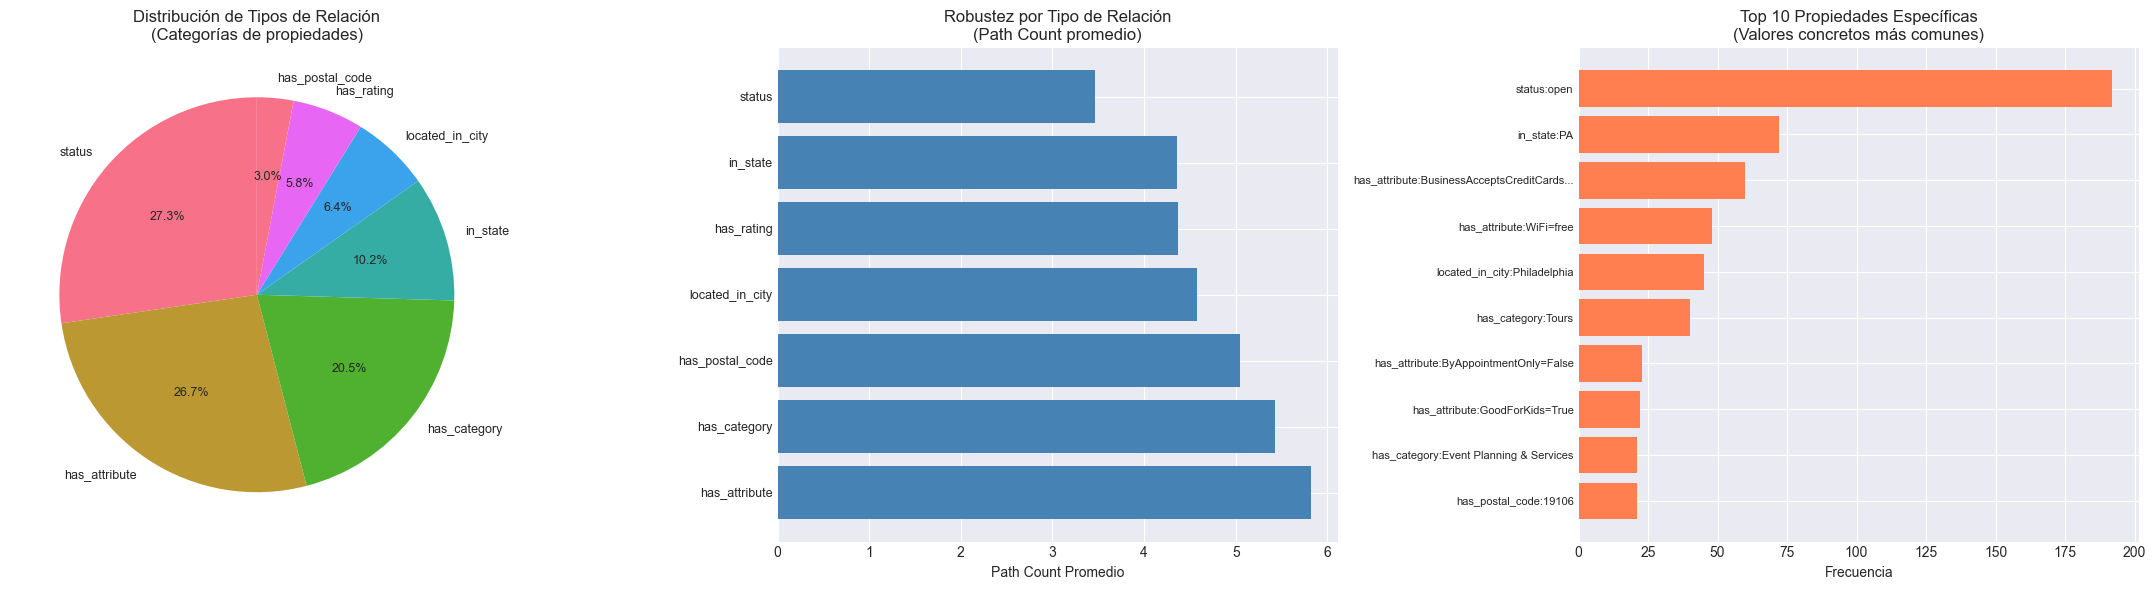

In [27]:
# %%
# 1.5 Análisis por tipo de propiedad (MEJORADO)
df_caminos['tipo_relacion'] = df_caminos['propiedad'].str.split(':').str[0]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- GRÁFICO 1: Distribución de tipos de relación (SIN CAMBIOS) ---
tipo_counts = df_caminos['tipo_relacion'].value_counts()
axes[0].pie(tipo_counts.values, labels=tipo_counts.index, autopct='%1.1f%%', 
            startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Distribución de Tipos de Relación\n(Categorías de propiedades)')

# --- GRÁFICO 2: Path Count promedio por tipo (SIN CAMBIOS) ---
path_count_by_type = df_caminos.groupby('tipo_relacion')['path_count'].mean().sort_values()
axes[1].barh(range(len(path_count_by_type)), path_count_by_type.values, color='steelblue')
axes[1].set_yticks(range(len(path_count_by_type)))
axes[1].set_yticklabels(path_count_by_type.index, fontsize=9)
axes[1].set_xlabel('Path Count Promedio')
axes[1].set_title('Robustez por Tipo de Relación\n(Path Count promedio)')
axes[1].invert_yaxis()

# --- GRÁFICO 3 (NUEVO): Top propiedades específicas más frecuentes ---
top_specific = df_caminos['propiedad'].value_counts().head(10)
axes[2].barh(range(len(top_specific)), top_specific.values, color='coral')
axes[2].set_yticks(range(len(top_specific)))
axes[2].set_yticklabels([prop[:40] + '...' if len(prop) > 40 else prop 
                          for prop in top_specific.index], 
                         fontsize=8)
axes[2].set_xlabel('Frecuencia')
axes[2].set_title('Top 10 Propiedades Específicas\n(Valores concretos más comunes)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('05_analisis_tipos_relacion_COMPLETO.png', dpi=300, bbox_inches='tight')
plt.show()

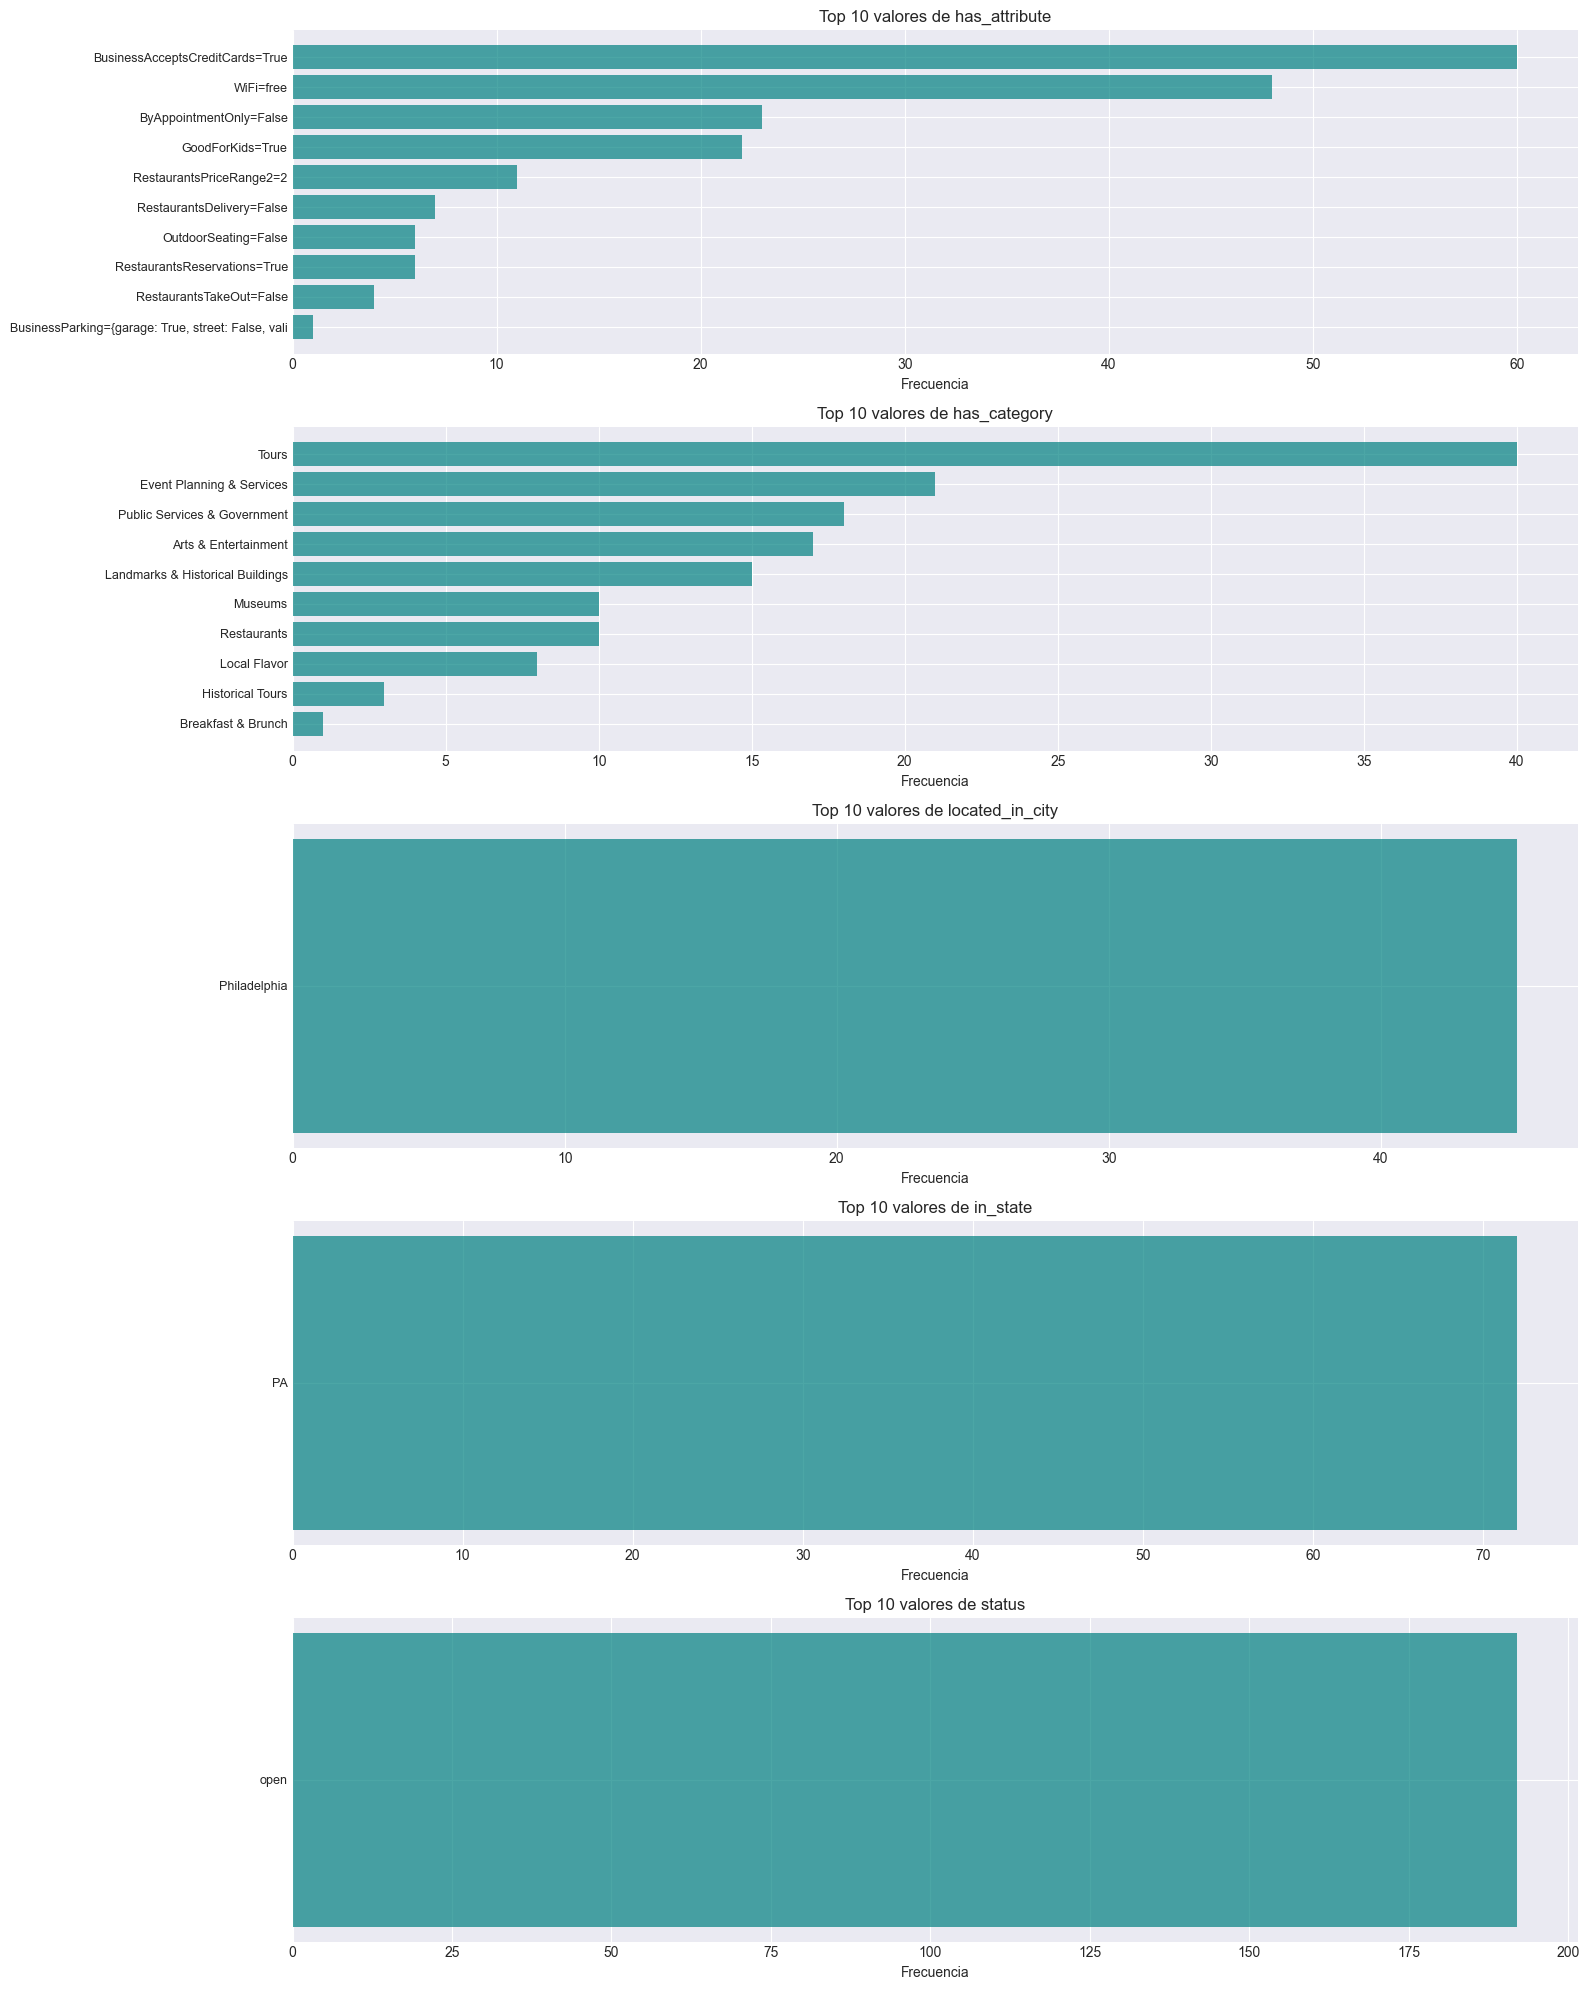

In [28]:
# %%
# BONUS: Top propiedades específicas por cada tipo de relación
tipos_principales = ['has_attribute', 'has_category', 'located_in_city', 'in_state', 'status']

fig, axes = plt.subplots(len(tipos_principales), 1, figsize=(16, 4*len(tipos_principales)))

for i, tipo in enumerate(tipos_principales):
    # Filtrar propiedades de este tipo
    df_tipo = df_caminos[df_caminos['tipo_relacion'] == tipo]
    
    if len(df_tipo) > 0:
        # Top 10 propiedades de este tipo
        top_tipo = df_tipo['propiedad'].value_counts().head(10)
        
        axes[i].barh(range(len(top_tipo)), top_tipo.values, color='teal', alpha=0.7)
        axes[i].set_yticks(range(len(top_tipo)))
        # Mostrar solo el valor después de los dos puntos (has_attribute:XXX → XXX)
        axes[i].set_yticklabels([prop.split(':', 1)[1][:50] if ':' in prop else prop 
                                  for prop in top_tipo.index], 
                                 fontsize=9)
        axes[i].set_xlabel('Frecuencia')
        axes[i].set_title(f'Top 10 valores de {tipo}')
        axes[i].invert_yaxis()
    else:
        axes[i].text(0.5, 0.5, f'No hay datos para {tipo}', 
                     ha='center', va='center', fontsize=12)
        axes[i].set_xlim(0, 1)
        axes[i].set_ylim(0, 1)
        axes[i].axis('off')

plt.tight_layout()
plt.savefig('22_desglose_propiedades_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()

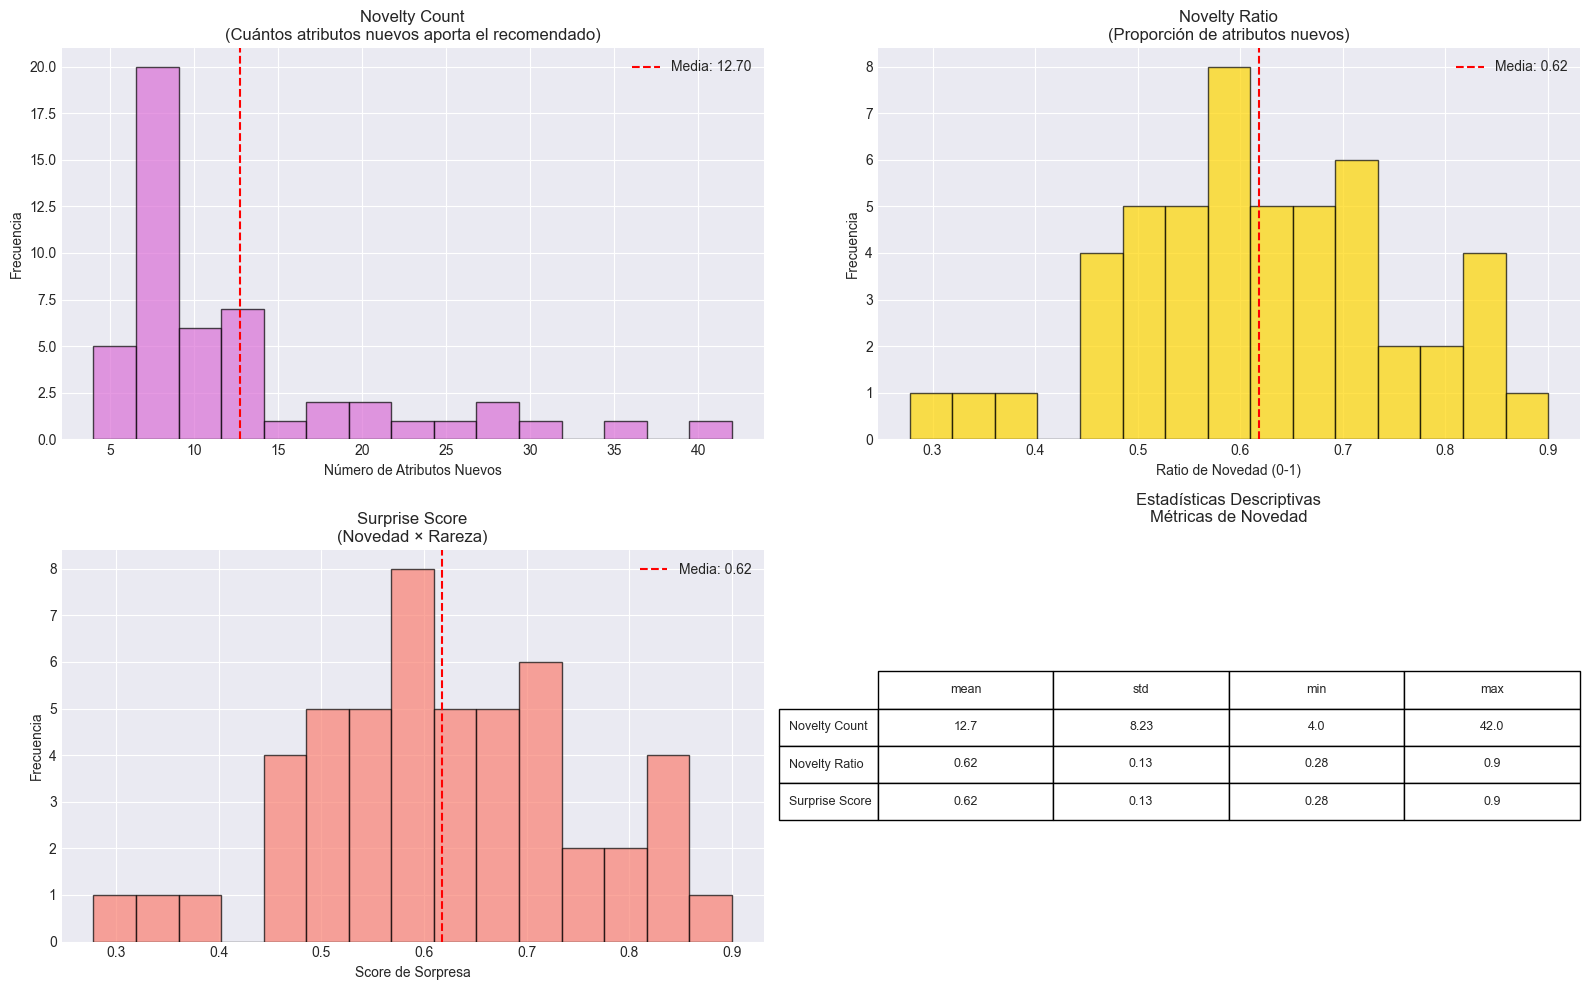

In [8]:
# %% [markdown]
# ---
# ## 2. ANÁLISIS DE MÉTRICAS GLOBALES (50 filas)
# 
# Evalúan novedad, sorpresa y cobertura de preferencias

# %%
# 2.1 Distribución de métricas de novedad
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Novelty Count
axes[0, 0].hist(df_globales['novelty_count'], bins=15, edgecolor='black', alpha=0.7, color='orchid')
axes[0, 0].set_xlabel('Número de Atributos Nuevos')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Novelty Count\n(Cuántos atributos nuevos aporta el recomendado)')
axes[0, 0].axvline(df_globales['novelty_count'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_globales["novelty_count"].mean():.2f}')
axes[0, 0].legend()

# Novelty Ratio
axes[0, 1].hist(df_globales['novelty_ratio'], bins=15, edgecolor='black', alpha=0.7, color='gold')
axes[0, 1].set_xlabel('Ratio de Novedad (0-1)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Novelty Ratio\n(Proporción de atributos nuevos)')
axes[0, 1].axvline(df_globales['novelty_ratio'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_globales["novelty_ratio"].mean():.2f}')
axes[0, 1].legend()

# Surprise Score
axes[1, 0].hist(df_globales['surprise_score'], bins=15, edgecolor='black', alpha=0.7, color='salmon')
axes[1, 0].set_xlabel('Score de Sorpresa')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Surprise Score\n(Novedad × Rareza)')
axes[1, 0].axvline(df_globales['surprise_score'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_globales["surprise_score"].mean():.2f}')
axes[1, 0].legend()

# Estadísticas combinadas
stats_data = {
    'Novelty Count': df_globales['novelty_count'].describe(),
    'Novelty Ratio': df_globales['novelty_ratio'].describe(),
    'Surprise Score': df_globales['surprise_score'].describe()
}
stats_df = pd.DataFrame(stats_data).T[['mean', 'std', 'min', 'max']]
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=stats_df.round(2).values,
                          rowLabels=stats_df.index,
                          colLabels=stats_df.columns,
                          cellLoc='center',
                          loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
axes[1, 1].set_title('Estadísticas Descriptivas\nMétricas de Novedad', pad=20)

plt.tight_layout()
plt.savefig('06_metricas_novedad.png', dpi=300, bbox_inches='tight')
plt.show()

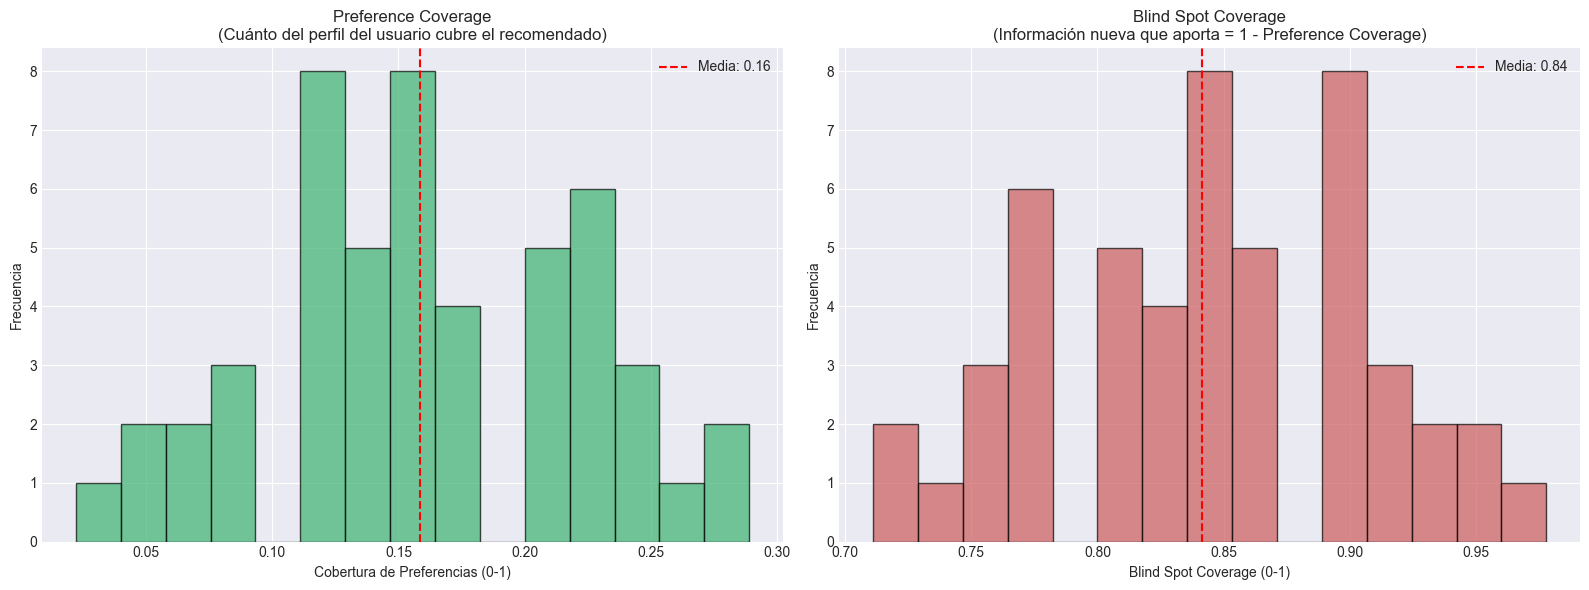

In [9]:
# %%
# 2.2 Métricas de cobertura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Preference Coverage
axes[0].hist(df_globales['preference_coverage'], bins=15, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0].set_xlabel('Cobertura de Preferencias (0-1)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Preference Coverage\n(Cuánto del perfil del usuario cubre el recomendado)')
axes[0].axvline(df_globales['preference_coverage'].mean(), color='red', linestyle='--',
                label=f'Media: {df_globales["preference_coverage"].mean():.2f}')
axes[0].legend()

# Blind Spot Coverage
axes[1].hist(df_globales['blind_spot_coverage'], bins=15, edgecolor='black', alpha=0.7, color='indianred')
axes[1].set_xlabel('Blind Spot Coverage (0-1)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Blind Spot Coverage\n(Información nueva que aporta = 1 - Preference Coverage)')
axes[1].axvline(df_globales['blind_spot_coverage'].mean(), color='red', linestyle='--',
                label=f'Media: {df_globales["blind_spot_coverage"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('07_metricas_cobertura.png', dpi=300, bbox_inches='tight')
plt.show()

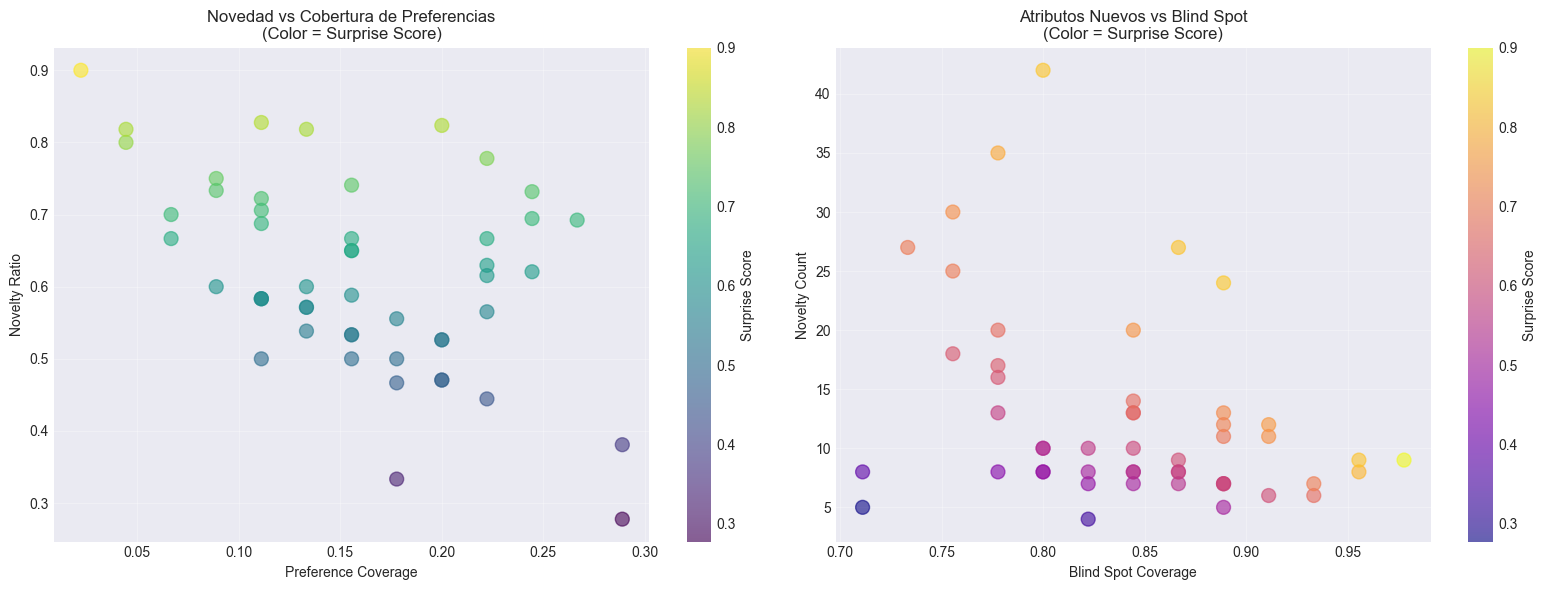

In [10]:
# %%
# 2.3 Relación entre novedad y cobertura
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Novelty Ratio vs Preference Coverage
axes[0].scatter(df_globales['preference_coverage'], df_globales['novelty_ratio'], 
                alpha=0.6, s=100, c=df_globales['surprise_score'], cmap='viridis')
axes[0].set_xlabel('Preference Coverage')
axes[0].set_ylabel('Novelty Ratio')
axes[0].set_title('Novedad vs Cobertura de Preferencias\n(Color = Surprise Score)')
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[0].collections[0], ax=axes[0])
cbar.set_label('Surprise Score')

# Novelty Count vs Blind Spot Coverage
axes[1].scatter(df_globales['blind_spot_coverage'], df_globales['novelty_count'], 
                alpha=0.6, s=100, c=df_globales['surprise_score'], cmap='plasma')
axes[1].set_xlabel('Blind Spot Coverage')
axes[1].set_ylabel('Novelty Count')
axes[1].set_title('Atributos Nuevos vs Blind Spot\n(Color = Surprise Score)')
axes[1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Surprise Score')

plt.tight_layout()
plt.savefig('08_novedad_vs_cobertura.png', dpi=300, bbox_inches='tight')
plt.show()

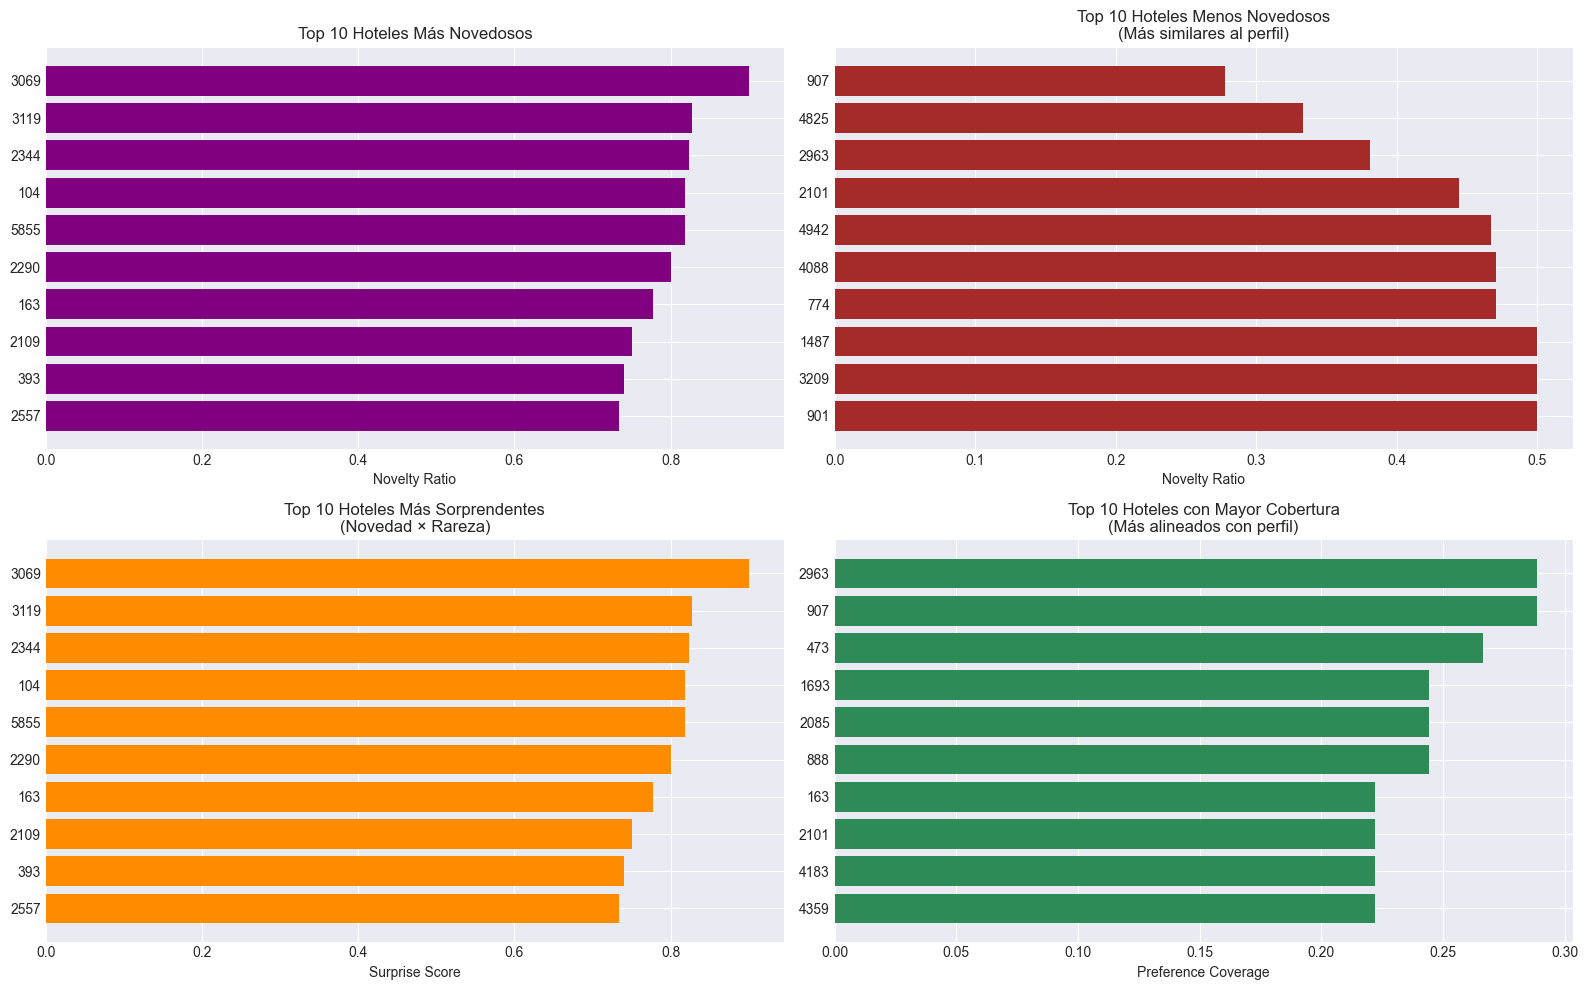

In [11]:
# %%
# 2.4 Top y Bottom hoteles recomendados por novedad y sorpresa
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top 10 hoteles por Novelty Ratio
top_novelty = df_globales.nlargest(10, 'novelty_ratio')[['hotel_recomendado', 'novelty_ratio']]
axes[0, 0].barh(range(len(top_novelty)), top_novelty['novelty_ratio'].values, color='purple')
axes[0, 0].set_yticks(range(len(top_novelty)))
axes[0, 0].set_yticklabels(top_novelty['hotel_recomendado'].values)
axes[0, 0].set_xlabel('Novelty Ratio')
axes[0, 0].set_title('Top 10 Hoteles Más Novedosos')
axes[0, 0].invert_yaxis()

# Bottom 10 hoteles por Novelty Ratio
bottom_novelty = df_globales.nsmallest(10, 'novelty_ratio')[['hotel_recomendado', 'novelty_ratio']]
axes[0, 1].barh(range(len(bottom_novelty)), bottom_novelty['novelty_ratio'].values, color='brown')
axes[0, 1].set_yticks(range(len(bottom_novelty)))
axes[0, 1].set_yticklabels(bottom_novelty['hotel_recomendado'].values)
axes[0, 1].set_xlabel('Novelty Ratio')
axes[0, 1].set_title('Top 10 Hoteles Menos Novedosos\n(Más similares al perfil)')
axes[0, 1].invert_yaxis()

# Top 10 hoteles por Surprise Score
top_surprise = df_globales.nlargest(10, 'surprise_score')[['hotel_recomendado', 'surprise_score']]
axes[1, 0].barh(range(len(top_surprise)), top_surprise['surprise_score'].values, color='darkorange')
axes[1, 0].set_yticks(range(len(top_surprise)))
axes[1, 0].set_yticklabels(top_surprise['hotel_recomendado'].values)
axes[1, 0].set_xlabel('Surprise Score')
axes[1, 0].set_title('Top 10 Hoteles Más Sorprendentes\n(Novedad × Rareza)')
axes[1, 0].invert_yaxis()

# Top 10 hoteles por Preference Coverage
top_coverage = df_globales.nlargest(10, 'preference_coverage')[['hotel_recomendado', 'preference_coverage']]
axes[1, 1].barh(range(len(top_coverage)), top_coverage['preference_coverage'].values, color='seagreen')
axes[1, 1].set_yticks(range(len(top_coverage)))
axes[1, 1].set_yticklabels(top_coverage['hotel_recomendado'].values)
axes[1, 1].set_xlabel('Preference Coverage')
axes[1, 1].set_title('Top 10 Hoteles con Mayor Cobertura\n(Más alineados con perfil)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('09_ranking_hoteles_globales.png', dpi=300, bbox_inches='tight')
plt.show()


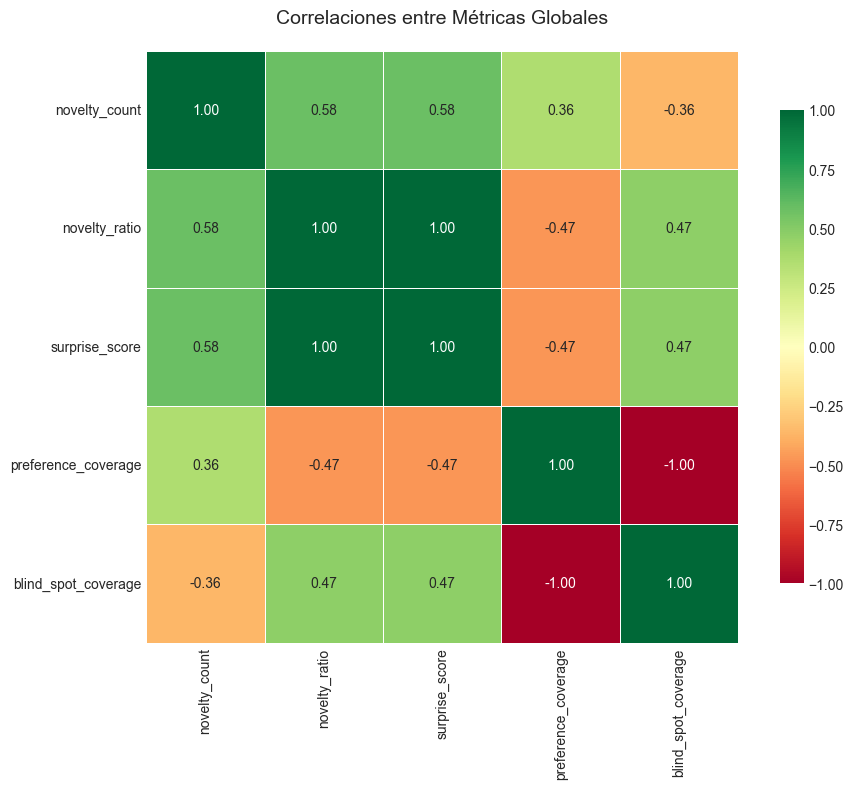

In [12]:
# %%
# 2.5 Heatmap de correlaciones globales
globales_numeric = df_globales[['novelty_count', 'novelty_ratio', 'surprise_score', 
                                'preference_coverage', 'blind_spot_coverage']]

plt.figure(figsize=(10, 8))
corr_matrix = globales_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlaciones entre Métricas Globales', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('10_correlaciones_globales.png', dpi=300, bbox_inches='tight')
plt.show()

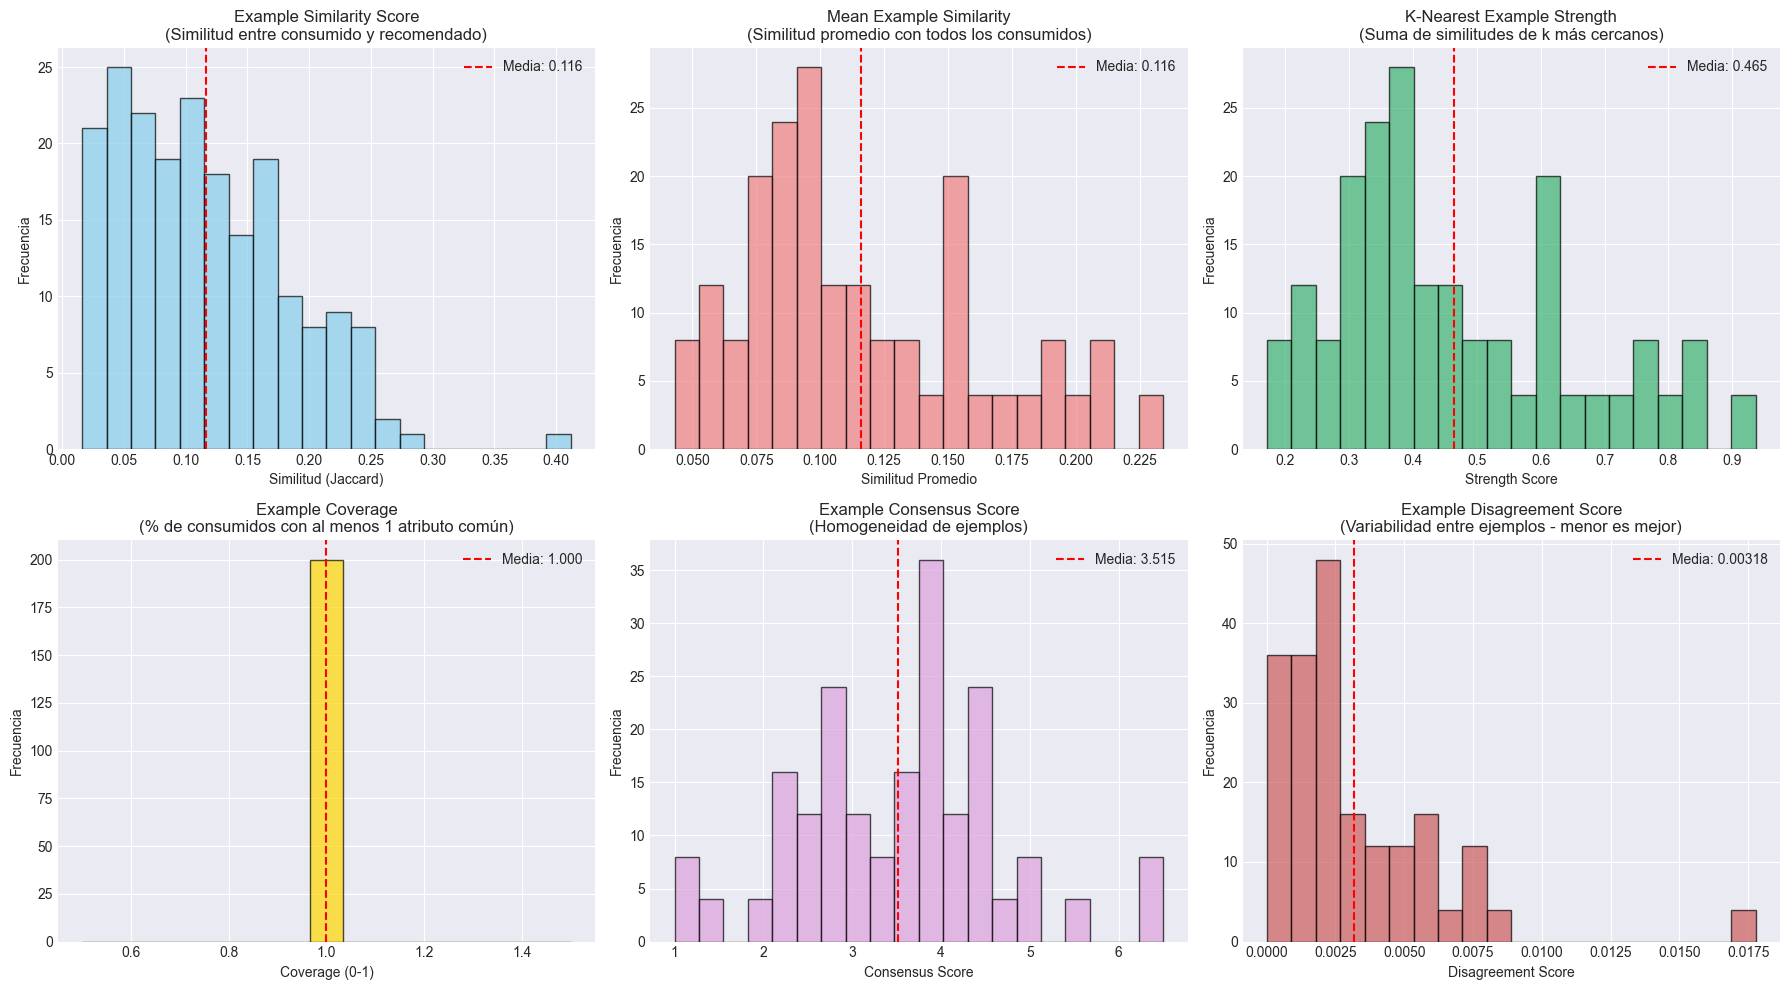

In [13]:
# %% [markdown]
# ---
# ## 3. ANÁLISIS DE MÉTRICAS NIVEL EJEMPLO (200 filas)
# 
# Comparan hoteles consumidos con recomendados usando similitud y ejemplos

# %%
# 3.1 Métricas de similitud entre ejemplos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Example Similarity Score
axes[0, 0].hist(df_ejemplos['example_similarity_score'], bins=20, 
                edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('Similitud (Jaccard)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Example Similarity Score\n(Similitud entre consumido y recomendado)')
axes[0, 0].axvline(df_ejemplos['example_similarity_score'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["example_similarity_score"].mean():.3f}')
axes[0, 0].legend()

# Mean Example Similarity
axes[0, 1].hist(df_ejemplos['mean_example_similarity'], bins=20, 
                edgecolor='black', alpha=0.7, color='lightcoral')
axes[0, 1].set_xlabel('Similitud Promedio')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Mean Example Similarity\n(Similitud promedio con todos los consumidos)')
axes[0, 1].axvline(df_ejemplos['mean_example_similarity'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["mean_example_similarity"].mean():.3f}')
axes[0, 1].legend()

# K-Nearest Example Strength
axes[0, 2].hist(df_ejemplos['k_nearest_example_strength'], bins=20, 
                edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0, 2].set_xlabel('Strength Score')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title('K-Nearest Example Strength\n(Suma de similitudes de k más cercanos)')
axes[0, 2].axvline(df_ejemplos['k_nearest_example_strength'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["k_nearest_example_strength"].mean():.3f}')
axes[0, 2].legend()

# Example Coverage
axes[1, 0].hist(df_ejemplos['example_coverage'], bins=15, 
                edgecolor='black', alpha=0.7, color='gold')
axes[1, 0].set_xlabel('Coverage (0-1)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Example Coverage\n(% de consumidos con al menos 1 atributo común)')
axes[1, 0].axvline(df_ejemplos['example_coverage'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["example_coverage"].mean():.3f}')
axes[1, 0].legend()

# Example Consensus Score
axes[1, 1].hist(df_ejemplos['example_consensus_score'], bins=20, 
                edgecolor='black', alpha=0.7, color='plum')
axes[1, 1].set_xlabel('Consensus Score')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Example Consensus Score\n(Homogeneidad de ejemplos)')
axes[1, 1].axvline(df_ejemplos['example_consensus_score'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["example_consensus_score"].mean():.3f}')
axes[1, 1].legend()

# Example Disagreement Score
axes[1, 2].hist(df_ejemplos['example_disagreement_score'], bins=20, 
                edgecolor='black', alpha=0.7, color='indianred')
axes[1, 2].set_xlabel('Disagreement Score')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].set_title('Example Disagreement Score\n(Variabilidad entre ejemplos - menor es mejor)')
axes[1, 2].axvline(df_ejemplos['example_disagreement_score'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["example_disagreement_score"].mean():.5f}')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('11_metricas_similitud_ejemplos.png', dpi=300, bbox_inches='tight')
plt.show()

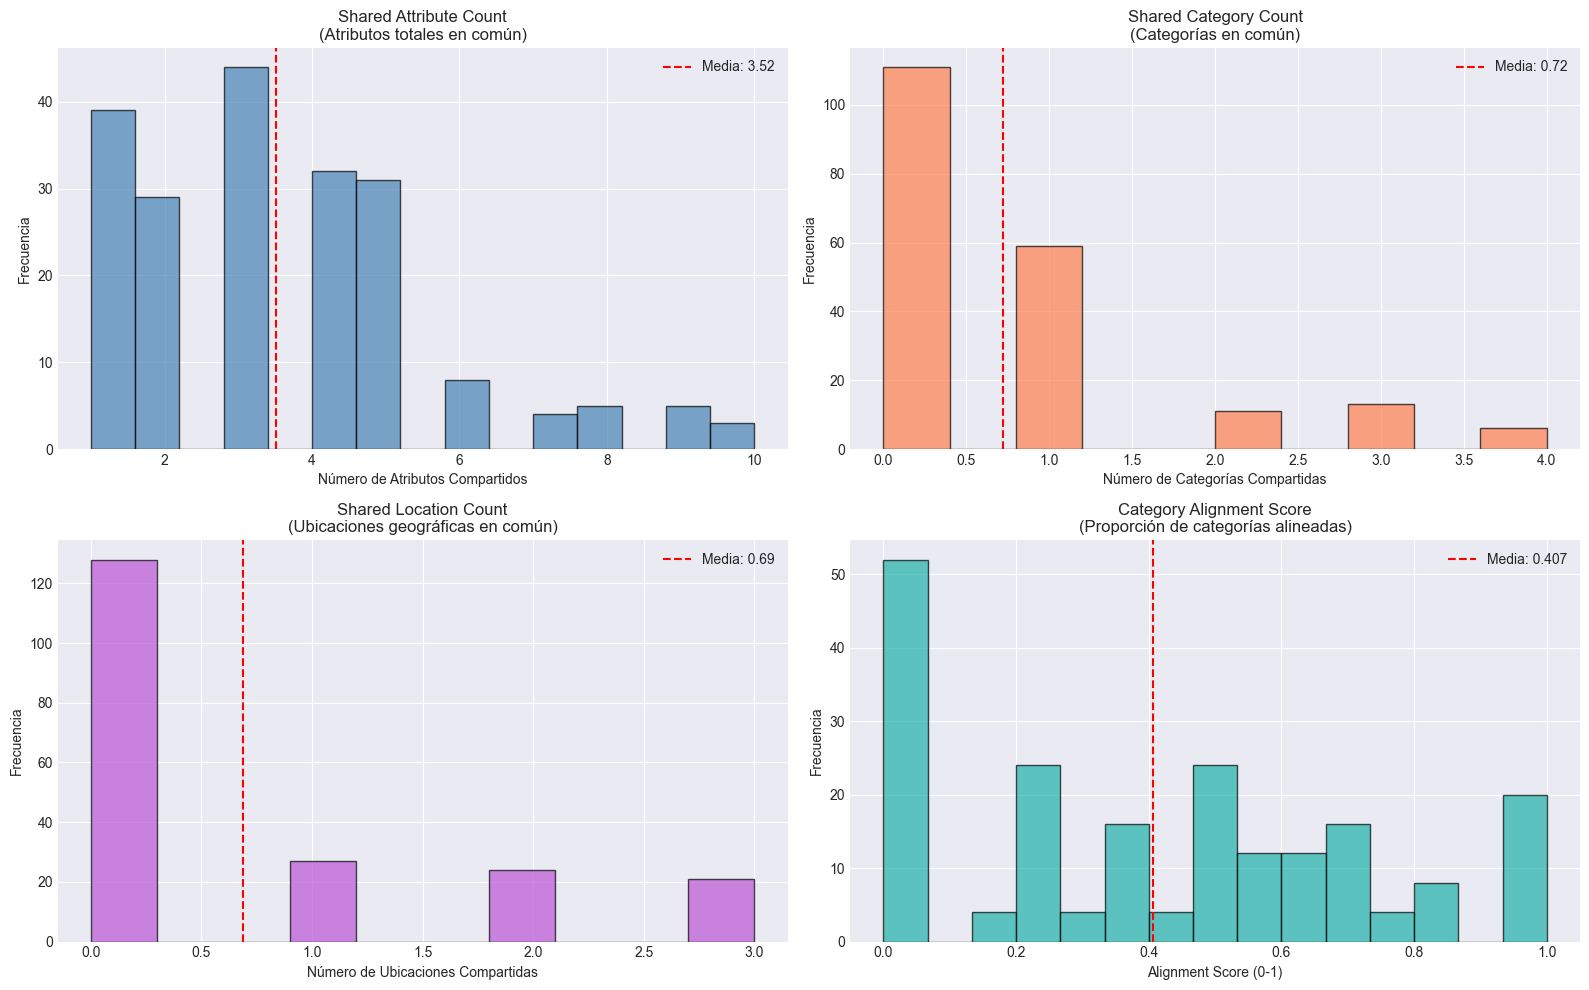

In [14]:
# %%
# 3.2 Métricas de atributos compartidos
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Shared Attribute Count
axes[0, 0].hist(df_ejemplos['shared_attribute_count'], bins=15, 
                edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Número de Atributos Compartidos')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Shared Attribute Count\n(Atributos totales en común)')
axes[0, 0].axvline(df_ejemplos['shared_attribute_count'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["shared_attribute_count"].mean():.2f}')
axes[0, 0].legend()

# Shared Category Count
axes[0, 1].hist(df_ejemplos['shared_category_count'], bins=10, 
                edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Número de Categorías Compartidas')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Shared Category Count\n(Categorías en común)')
axes[0, 1].axvline(df_ejemplos['shared_category_count'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["shared_category_count"].mean():.2f}')
axes[0, 1].legend()

# Shared Location Count
axes[1, 0].hist(df_ejemplos['shared_location_count'], bins=10, 
                edgecolor='black', alpha=0.7, color='mediumorchid')
axes[1, 0].set_xlabel('Número de Ubicaciones Compartidas')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Shared Location Count\n(Ubicaciones geográficas en común)')
axes[1, 0].axvline(df_ejemplos['shared_location_count'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["shared_location_count"].mean():.2f}')
axes[1, 0].legend()

# Category Alignment Score
axes[1, 1].hist(df_ejemplos['category_alignment_score'], bins=15, 
                edgecolor='black', alpha=0.7, color='lightseagreen')
axes[1, 1].set_xlabel('Alignment Score (0-1)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Category Alignment Score\n(Proporción de categorías alineadas)')
axes[1, 1].axvline(df_ejemplos['category_alignment_score'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_ejemplos["category_alignment_score"].mean():.3f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('12_atributos_compartidos_ejemplos.png', dpi=300, bbox_inches='tight')
plt.show()

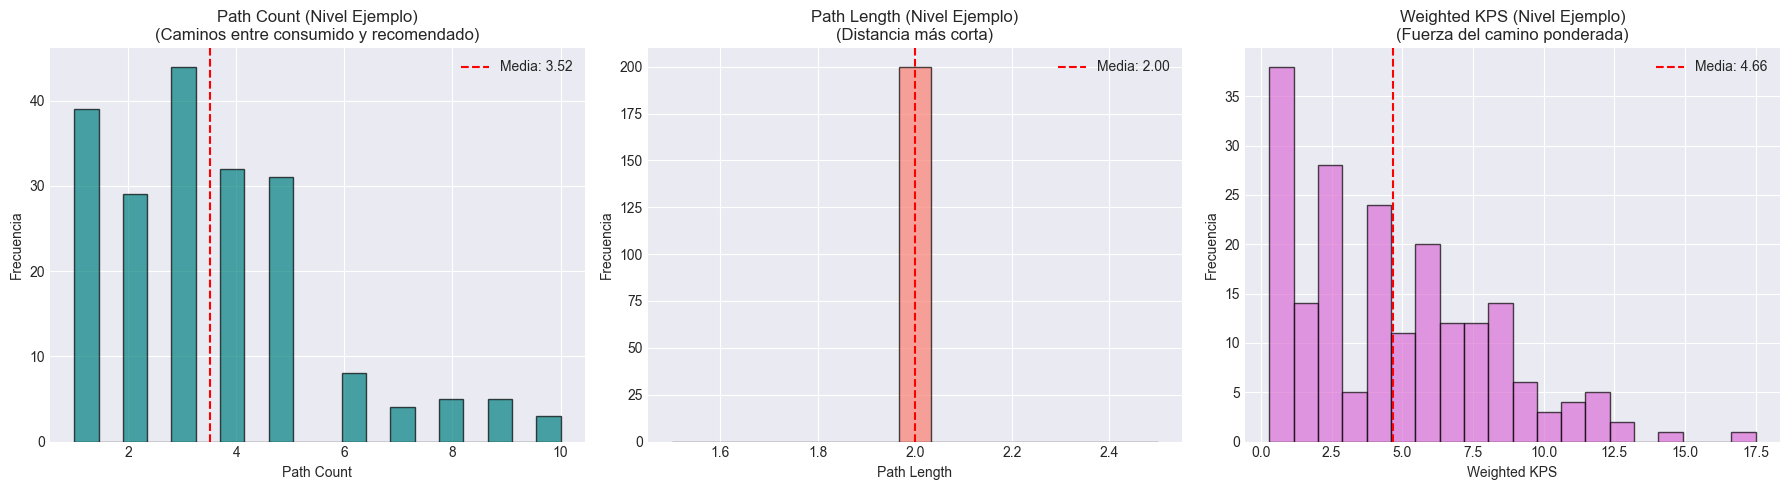

In [15]:
# %%
# 3.3 Análisis de path metrics en ejemplos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Path Count en ejemplos
axes[0].hist(df_ejemplos['path_count'], bins=20, edgecolor='black', alpha=0.7, color='teal')
axes[0].set_xlabel('Path Count')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Path Count (Nivel Ejemplo)\n(Caminos entre consumido y recomendado)')
axes[0].axvline(df_ejemplos['path_count'].mean(), color='red', linestyle='--',
                label=f'Media: {df_ejemplos["path_count"].mean():.2f}')
axes[0].legend()

# Path Length en ejemplos
axes[1].hist(df_ejemplos['path_length'], bins=15, edgecolor='black', alpha=0.7, color='salmon')
axes[1].set_xlabel('Path Length')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Path Length (Nivel Ejemplo)\n(Distancia más corta)')
axes[1].axvline(df_ejemplos['path_length'].mean(), color='red', linestyle='--',
                label=f'Media: {df_ejemplos["path_length"].mean():.2f}')
axes[1].legend()

# Weighted KPS en ejemplos
axes[2].hist(df_ejemplos['weighted_kps'], bins=20, edgecolor='black', alpha=0.7, color='orchid')
axes[2].set_xlabel('Weighted KPS')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Weighted KPS (Nivel Ejemplo)\n(Fuerza del camino ponderada)')
axes[2].axvline(df_ejemplos['weighted_kps'].mean(), color='red', linestyle='--',
                label=f'Media: {df_ejemplos["weighted_kps"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('13_path_metrics_ejemplos.png', dpi=300, bbox_inches='tight')
plt.show()


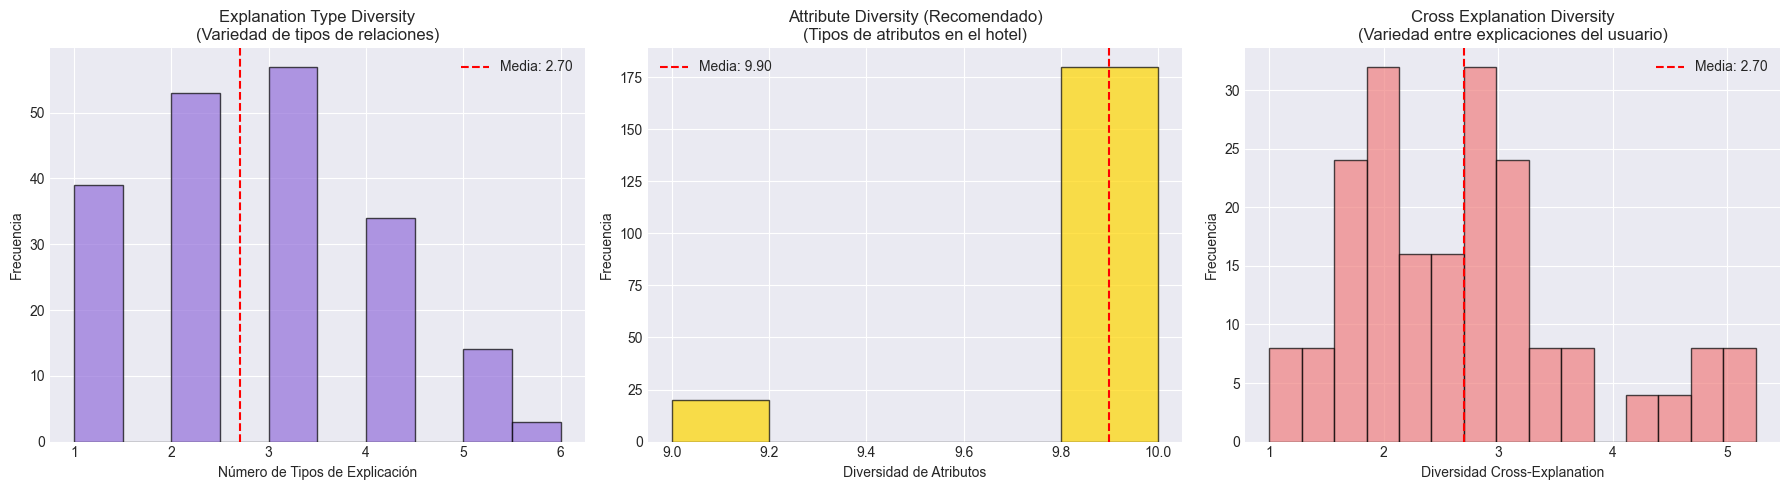

In [16]:
# %%
# 3.4 Métricas de diversidad en ejemplos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Explanation Type Diversity
axes[0].hist(df_ejemplos['explanation_type_diversity'], bins=10, 
             edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0].set_xlabel('Número de Tipos de Explicación')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Explanation Type Diversity\n(Variedad de tipos de relaciones)')
axes[0].axvline(df_ejemplos['explanation_type_diversity'].mean(), 
                color='red', linestyle='--', label=f'Media: {df_ejemplos["explanation_type_diversity"].mean():.2f}')
axes[0].legend()

# Attribute Diversity Recommended
axes[1].hist(df_ejemplos['attribute_diversity_recommended'], bins=5, 
             edgecolor='black', alpha=0.7, color='gold')
axes[1].set_xlabel('Diversidad de Atributos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Attribute Diversity (Recomendado)\n(Tipos de atributos en el hotel)')
axes[1].axvline(df_ejemplos['attribute_diversity_recommended'].mean(), 
                color='red', linestyle='--', label=f'Media: {df_ejemplos["attribute_diversity_recommended"].mean():.2f}')
axes[1].legend()

# Cross Explanation Diversity
axes[2].hist(df_ejemplos['cross_explanation_diversity'], bins=15, 
             edgecolor='black', alpha=0.7, color='lightcoral')
axes[2].set_xlabel('Diversidad Cross-Explanation')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Cross Explanation Diversity\n(Variedad entre explicaciones del usuario)')
axes[2].axvline(df_ejemplos['cross_explanation_diversity'].mean(), 
                color='red', linestyle='--', label=f'Media: {df_ejemplos["cross_explanation_diversity"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('14_diversidad_ejemplos.png', dpi=300, bbox_inches='tight')
plt.show()


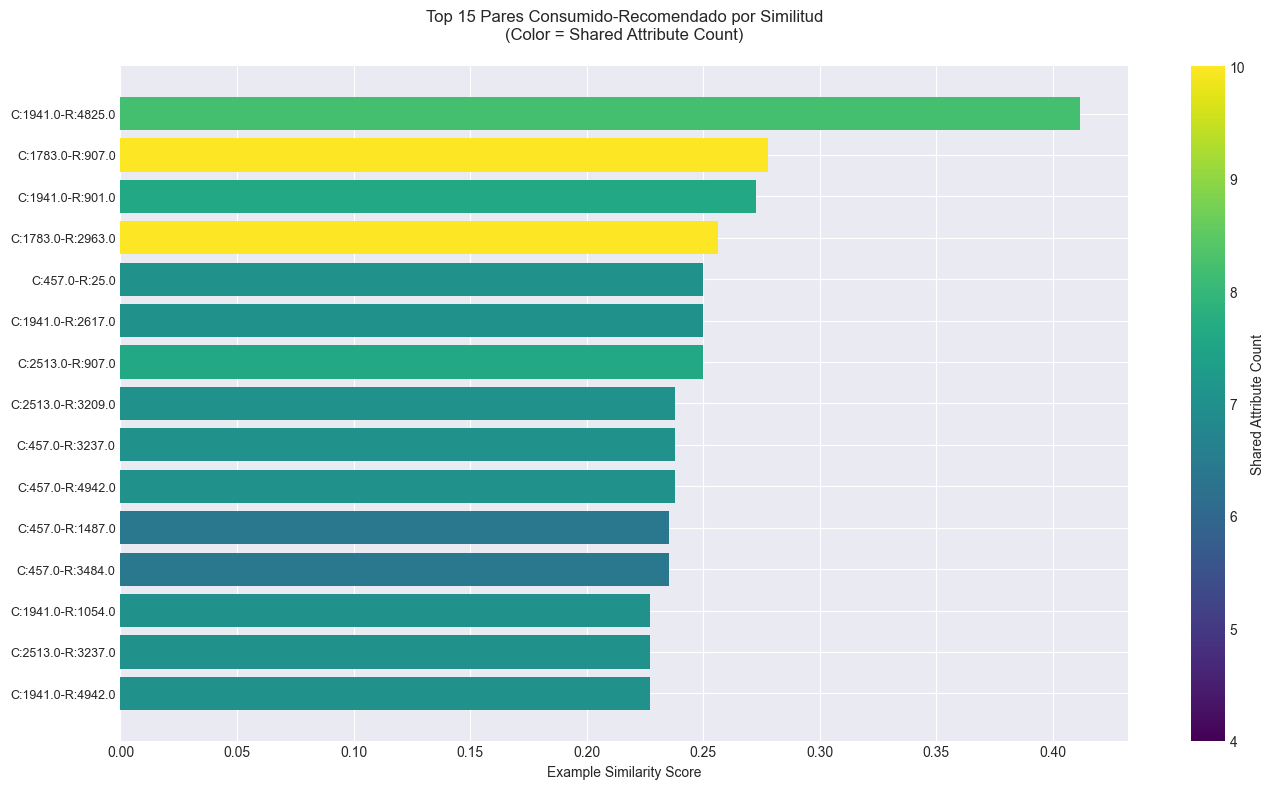

In [17]:
# %%
# 3.5 Top pares consumido-recomendado por similitud
top_pairs = df_ejemplos.nlargest(15, 'example_similarity_score')[
    ['hotel_consumido', 'hotel_recomendado', 'example_similarity_score', 'shared_attribute_count']
]

fig, ax = plt.subplots(figsize=(14, 8))
pairs_labels = [f"C:{row['hotel_consumido']}-R:{row['hotel_recomendado']}" 
                for _, row in top_pairs.iterrows()]
colors = plt.cm.viridis(top_pairs['shared_attribute_count'] / top_pairs['shared_attribute_count'].max())

bars = ax.barh(range(len(top_pairs)), top_pairs['example_similarity_score'].values, color=colors)
ax.set_yticks(range(len(top_pairs)))
ax.set_yticklabels(pairs_labels, fontsize=9)
ax.set_xlabel('Example Similarity Score')
ax.set_title('Top 15 Pares Consumido-Recomendado por Similitud\n(Color = Shared Attribute Count)', pad=20)
ax.invert_yaxis()

# Agregar barra de color
sm = plt.cm.ScalarMappable(cmap='viridis', 
                           norm=plt.Normalize(vmin=top_pairs['shared_attribute_count'].min(), 
                                             vmax=top_pairs['shared_attribute_count'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Shared Attribute Count')

plt.tight_layout()
plt.savefig('15_top_pares_similitud.png', dpi=300, bbox_inches='tight')
plt.show()

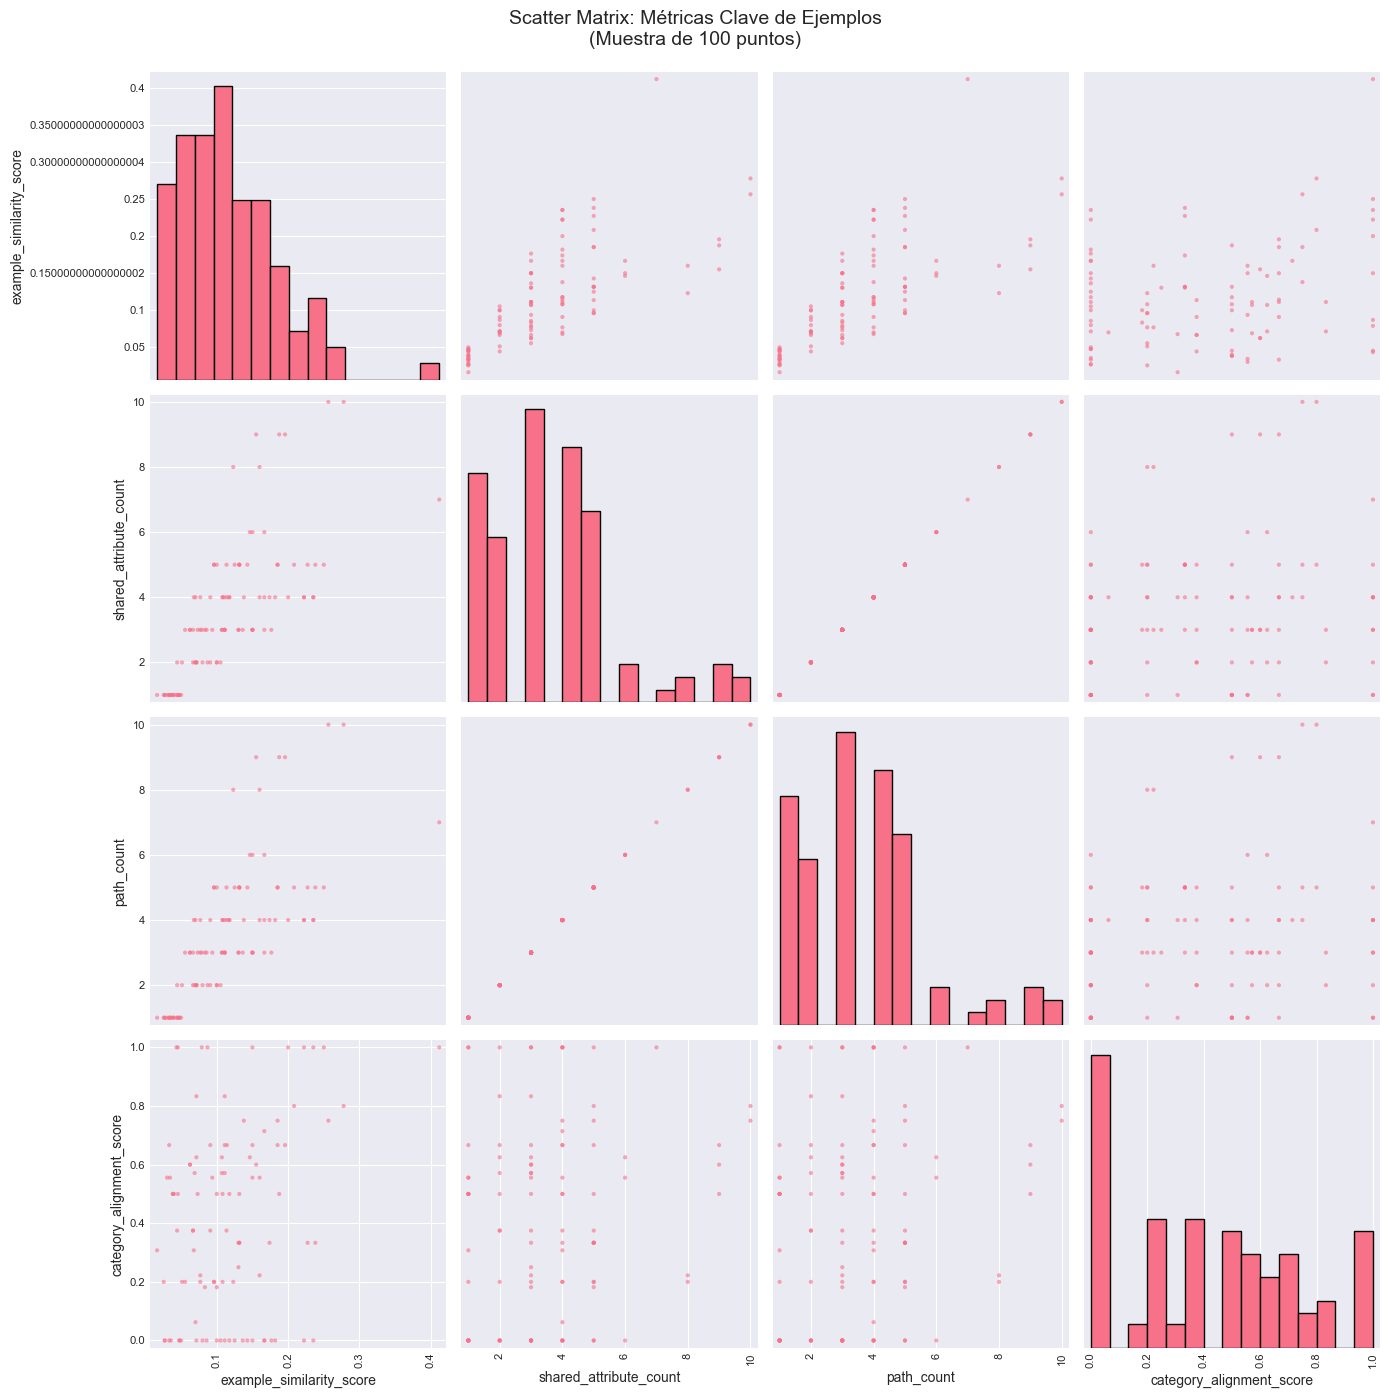

In [18]:
# %%
# 3.6 Scatter matrix de métricas clave
ejemplos_sample = df_ejemplos[['example_similarity_score', 'shared_attribute_count', 
                                'path_count', 'category_alignment_score']].sample(min(100, len(df_ejemplos)))

pd.plotting.scatter_matrix(ejemplos_sample, figsize=(14, 14), alpha=0.6, 
                           diagonal='hist', hist_kwds={'bins': 15, 'edgecolor': 'black'})
plt.suptitle('Scatter Matrix: Métricas Clave de Ejemplos\n(Muestra de 100 puntos)', 
             y=0.995, fontsize=14)
plt.tight_layout()
plt.savefig('16_scatter_matrix_ejemplos.png', dpi=300, bbox_inches='tight')
plt.show()

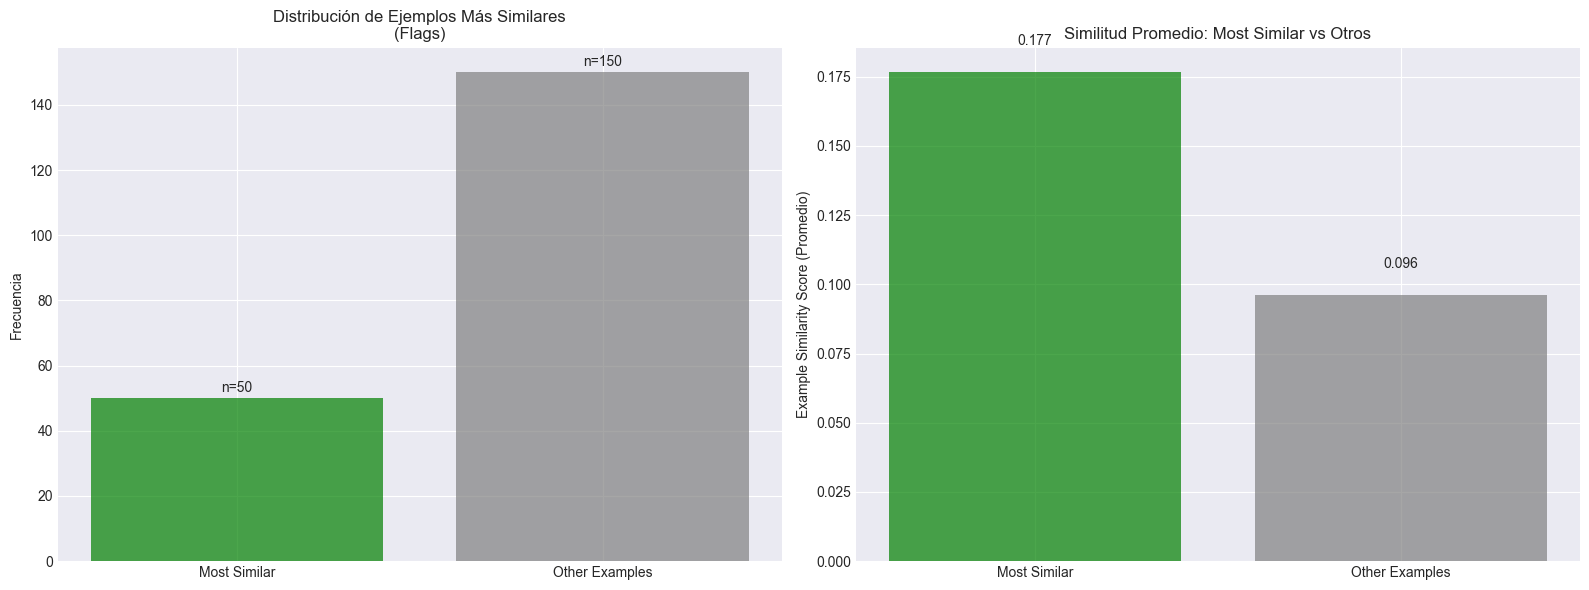

In [19]:
# %%
# 3.7 Análisis de ejemplos más y menos similares
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contar cuántos hoteles son marcados como más similares
most_similar = df_ejemplos[df_ejemplos['is_most_similar'] == 1]
axes[0].bar(['Most Similar', 'Other Examples'], 
            [len(most_similar), len(df_ejemplos) - len(most_similar)],
            color=['green', 'gray'], alpha=0.7)
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Ejemplos Más Similares\n(Flags)')
axes[0].text(0, len(most_similar) + 2, f'n={len(most_similar)}', ha='center')
axes[0].text(1, len(df_ejemplos) - len(most_similar) + 2, 
             f'n={len(df_ejemplos) - len(most_similar)}', ha='center')

# Comparar similitud promedio de más similares vs otros
most_sim_avg = most_similar['example_similarity_score'].mean()
other_avg = df_ejemplos[df_ejemplos['is_most_similar'] == 0]['example_similarity_score'].mean()
axes[1].bar(['Most Similar', 'Other Examples'], [most_sim_avg, other_avg],
            color=['green', 'gray'], alpha=0.7)
axes[1].set_ylabel('Example Similarity Score (Promedio)')
axes[1].set_title('Similitud Promedio: Most Similar vs Otros')
axes[1].text(0, most_sim_avg + 0.01, f'{most_sim_avg:.3f}', ha='center')
axes[1].text(1, other_avg + 0.01, f'{other_avg:.3f}', ha='center')

plt.tight_layout()
plt.savefig('17_analisis_most_similar.png', dpi=300, bbox_inches='tight')
plt.show()

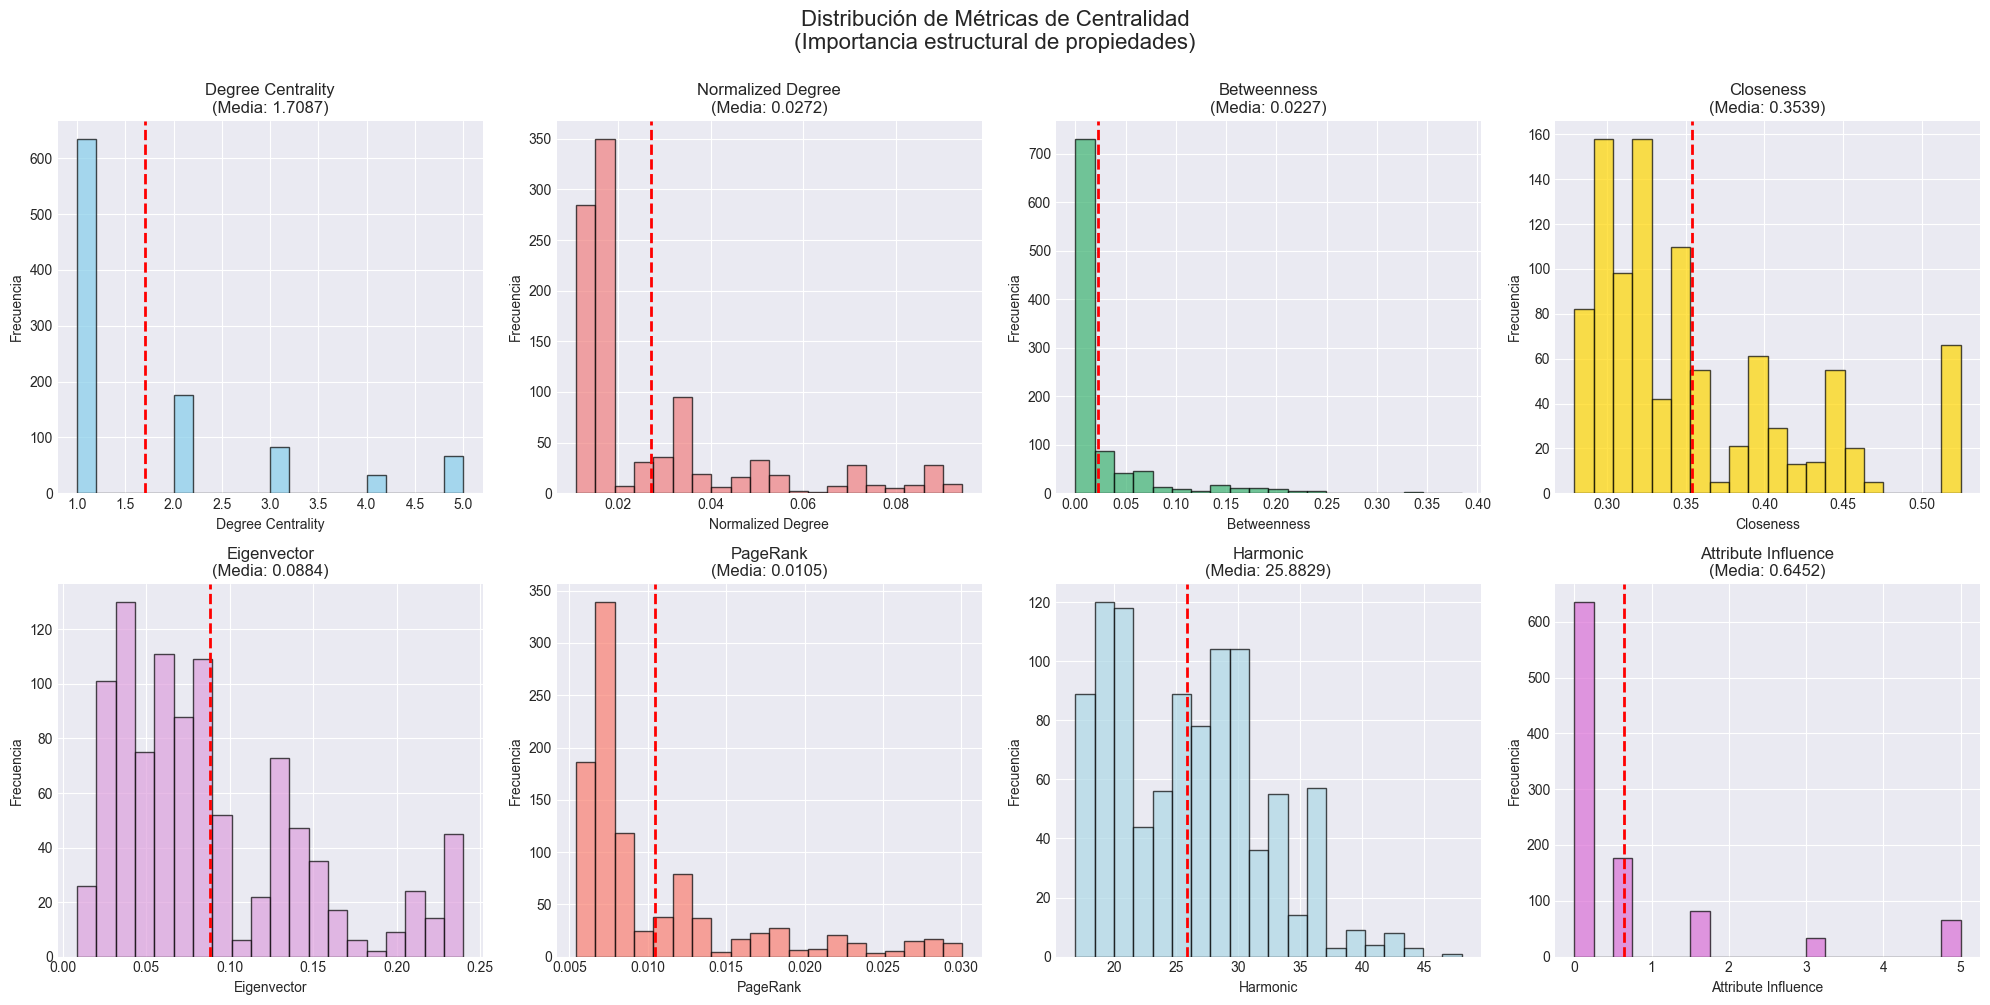

In [20]:
# %% [markdown]
# ---
# ## 4. ANÁLISIS DE MÉTRICAS NIVEL PROPIEDAD (992 filas)
# 
# Evalúan centralidad, contenido y popularidad de propiedades

# %%
# 4.1 Métricas de centralidad
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

centrality_metrics = [
    ('degree_centrality', 'Degree Centrality', 'skyblue'),
    ('normalized_degree_centrality', 'Normalized Degree', 'lightcoral'),
    ('betweenness_centrality', 'Betweenness', 'mediumseagreen'),
    ('closeness_centrality', 'Closeness', 'gold'),
    ('eigenvector_centrality', 'Eigenvector', 'plum'),
    ('pagerank', 'PageRank', 'salmon'),
    ('harmonic_centrality', 'Harmonic', 'lightblue'),
    ('attribute_influence_score', 'Attribute Influence', 'orchid')
]

for idx, (metric, title, color) in enumerate(centrality_metrics):
    row = idx // 4
    col = idx % 4
    axes[row, col].hist(df_propiedad[metric], bins=20, edgecolor='black', alpha=0.7, color=color)
    axes[row, col].set_xlabel(title)
    axes[row, col].set_ylabel('Frecuencia')
    axes[row, col].set_title(f'{title}\n(Media: {df_propiedad[metric].mean():.4f})')
    axes[row, col].axvline(df_propiedad[metric].mean(), color='red', linestyle='--', linewidth=2)

plt.suptitle('Distribución de Métricas de Centralidad\n(Importancia estructural de propiedades)', 
             fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('18_centralidad_propiedades.png', dpi=300, bbox_inches='tight')
plt.show()

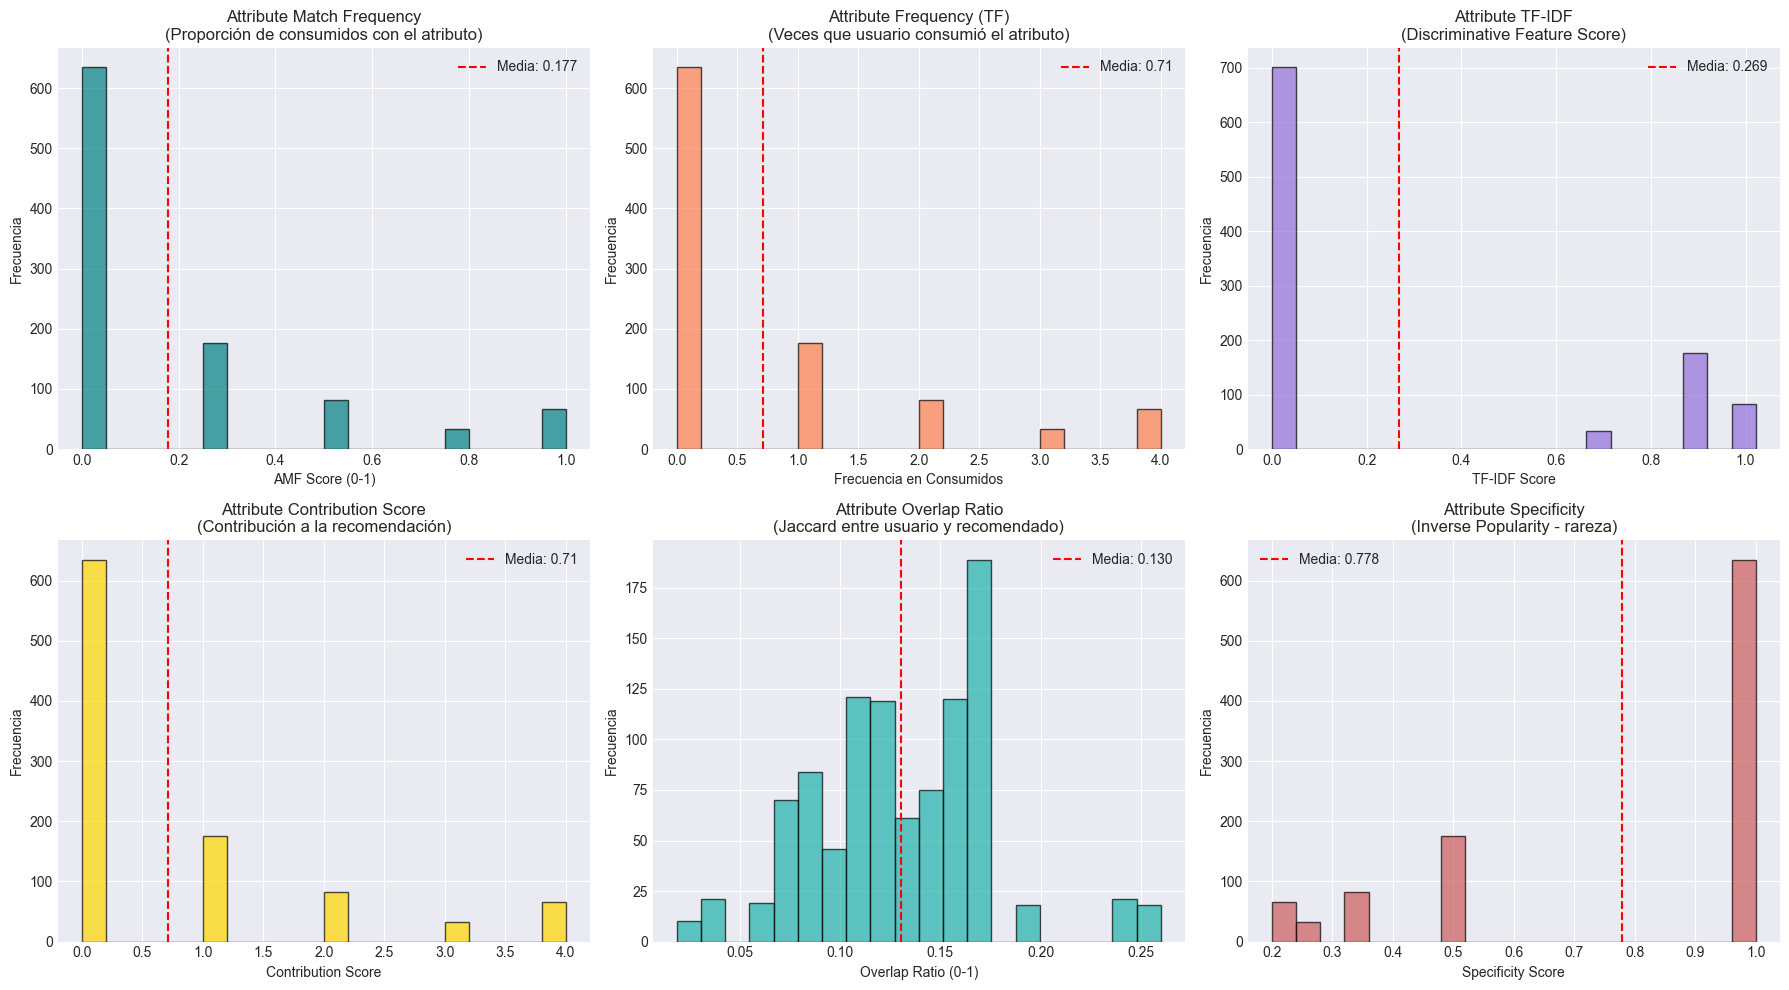

In [21]:
# %%
# 4.2 Métricas de contenido (AMF, TF-IDF, etc.)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# AMF (Attribute Match Frequency)
axes[0, 0].hist(df_propiedad['amf'], bins=20, edgecolor='black', alpha=0.7, color='teal')
axes[0, 0].set_xlabel('AMF Score (0-1)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Attribute Match Frequency\n(Proporción de consumidos con el atributo)')
axes[0, 0].axvline(df_propiedad['amf'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_propiedad["amf"].mean():.3f}')
axes[0, 0].legend()

# Attribute Frequency (TF)
axes[0, 1].hist(df_propiedad['attribute_frequency'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Frecuencia en Consumidos')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Attribute Frequency (TF)\n(Veces que usuario consumió el atributo)')
axes[0, 1].axvline(df_propiedad['attribute_frequency'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_propiedad["attribute_frequency"].mean():.2f}')
axes[0, 1].legend()

# Attribute TF-IDF
axes[0, 2].hist(df_propiedad['attribute_tfidf'], bins=20, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0, 2].set_xlabel('TF-IDF Score')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title('Attribute TF-IDF\n(Discriminative Feature Score)')
axes[0, 2].axvline(df_propiedad['attribute_tfidf'].mean(), color='red', linestyle='--',
                    label=f'Media: {df_propiedad["attribute_tfidf"].mean():.3f}')
axes[0, 2].legend()

# Attribute Contribution Score
axes[1, 0].hist(df_propiedad['attribute_contribution_score'], bins=20, 
                edgecolor='black', alpha=0.7, color='gold')
axes[1, 0].set_xlabel('Contribution Score')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Attribute Contribution Score\n(Contribución a la recomendación)')
axes[1, 0].axvline(df_propiedad['attribute_contribution_score'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_propiedad["attribute_contribution_score"].mean():.2f}')
axes[1, 0].legend()

# Attribute Overlap Ratio
axes[1, 1].hist(df_propiedad['attribute_overlap_ratio'], bins=20, 
                edgecolor='black', alpha=0.7, color='lightseagreen')
axes[1, 1].set_xlabel('Overlap Ratio (0-1)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Attribute Overlap Ratio\n(Jaccard entre usuario y recomendado)')
axes[1, 1].axvline(df_propiedad['attribute_overlap_ratio'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_propiedad["attribute_overlap_ratio"].mean():.3f}')
axes[1, 1].legend()

# Attribute Specificity
axes[1, 2].hist(df_propiedad['attribute_specificity'], bins=20, 
                edgecolor='black', alpha=0.7, color='indianred')
axes[1, 2].set_xlabel('Specificity Score')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].set_title('Attribute Specificity\n(Inverse Popularity - rareza)')
axes[1, 2].axvline(df_propiedad['attribute_specificity'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_propiedad["attribute_specificity"].mean():.3f}')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('19_metricas_contenido.png', dpi=300, bbox_inches='tight')
plt.show()

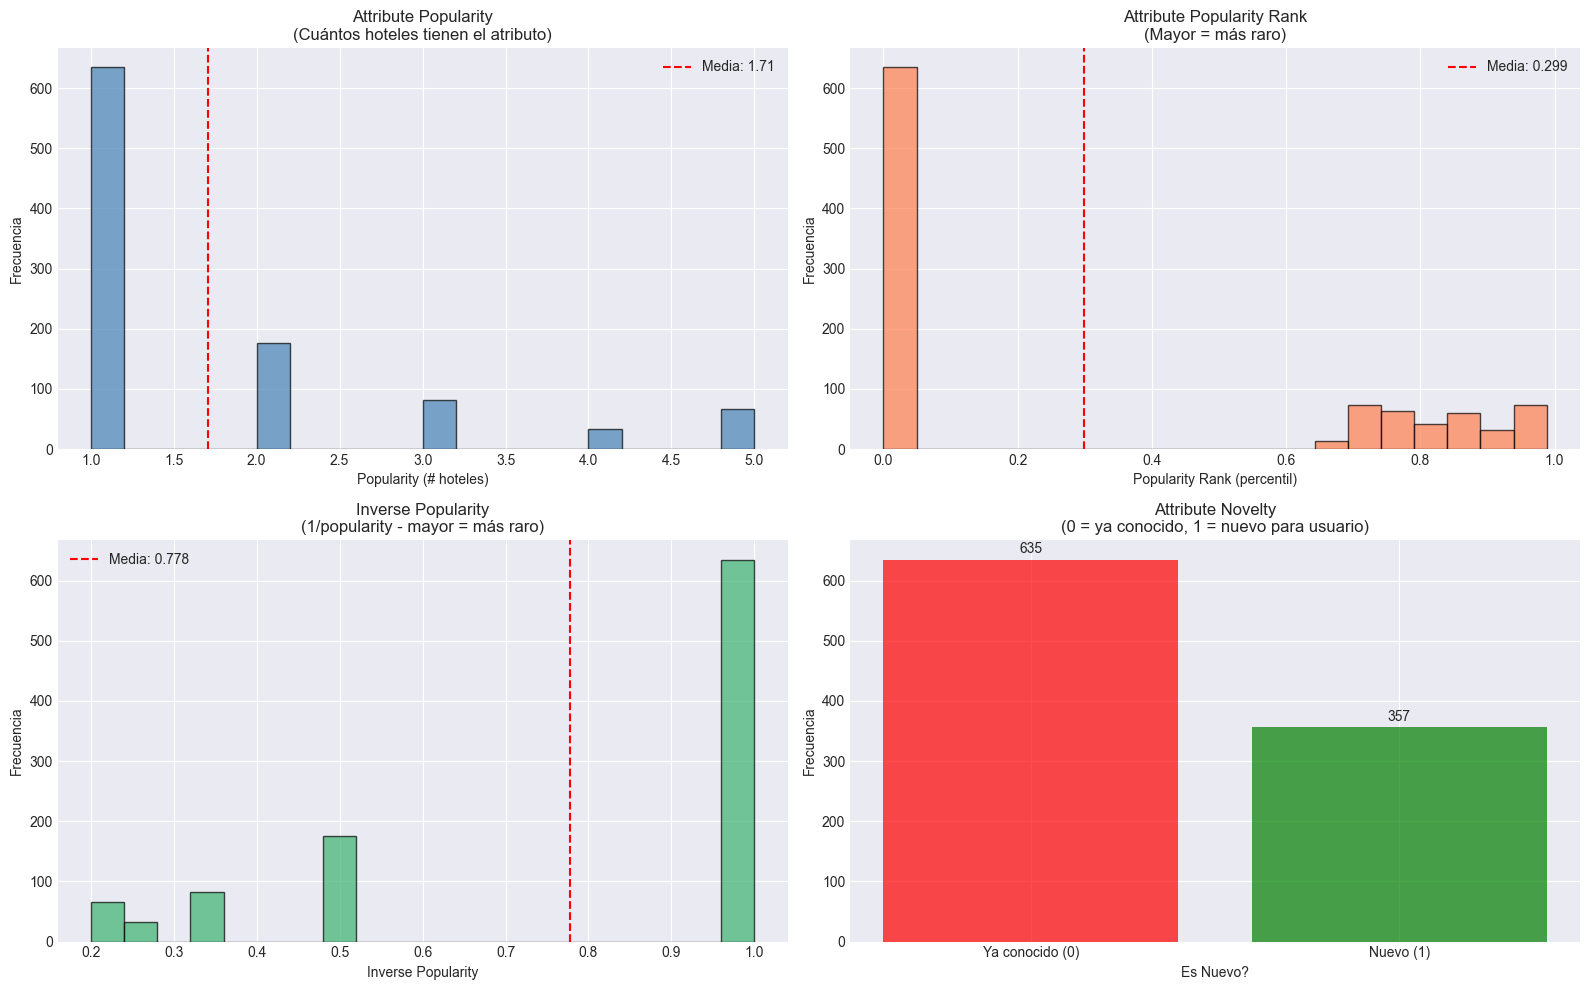

In [22]:
# %%
# 4.3 Métricas de popularidad
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Attribute Popularity
axes[0, 0].hist(df_propiedad['attribute_popularity'], bins=20, 
                edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Popularity (# hoteles)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Attribute Popularity\n(Cuántos hoteles tienen el atributo)')
axes[0, 0].axvline(df_propiedad['attribute_popularity'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_propiedad["attribute_popularity"].mean():.2f}')
axes[0, 0].legend()

# Attribute Popularity Rank
axes[0, 1].hist(df_propiedad['attribute_popularity_rank'], bins=20, 
                edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Popularity Rank (percentil)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Attribute Popularity Rank\n(Mayor = más raro)')
axes[0, 1].axvline(df_propiedad['attribute_popularity_rank'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_propiedad["attribute_popularity_rank"].mean():.3f}')
axes[0, 1].legend()

# Inverse Popularity
axes[1, 0].hist(df_propiedad['inverse_popularity'], bins=20, 
                edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[1, 0].set_xlabel('Inverse Popularity')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Inverse Popularity\n(1/popularity - mayor = más raro)')
axes[1, 0].axvline(df_propiedad['inverse_popularity'].mean(), 
                    color='red', linestyle='--', label=f'Media: {df_propiedad["inverse_popularity"].mean():.3f}')
axes[1, 0].legend()

# Attribute Novelty
novelty_counts = df_propiedad['attribute_novelty'].value_counts()
axes[1, 1].bar(novelty_counts.index.astype(str), novelty_counts.values, 
               color=['red', 'green'], alpha=0.7)
axes[1, 1].set_xlabel('Es Nuevo?')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Attribute Novelty\n(0 = ya conocido, 1 = nuevo para usuario)')
axes[1, 1].set_xticklabels(['Ya conocido (0)', 'Nuevo (1)'])
for i, v in enumerate(novelty_counts.values):
    axes[1, 1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.savefig('20_metricas_popularidad.png', dpi=300, bbox_inches='tight')
plt.show()

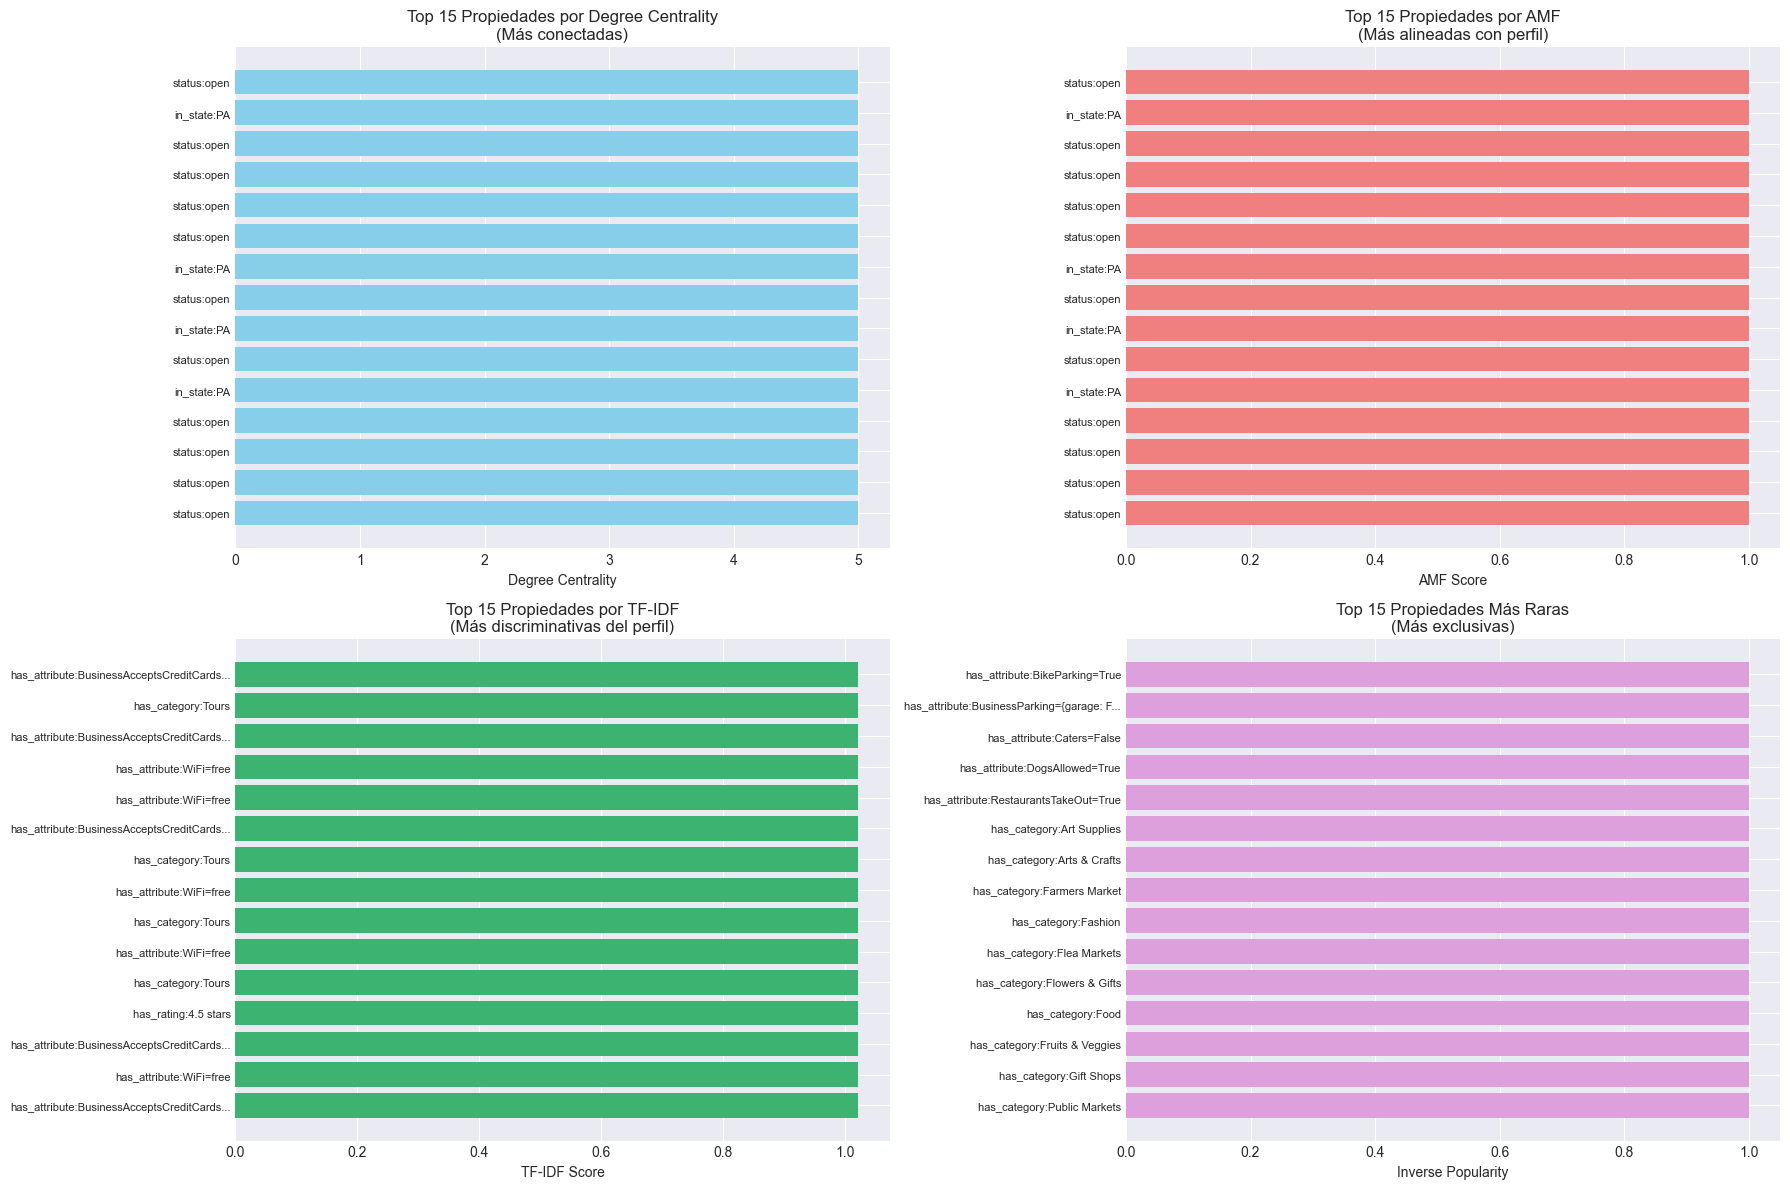

In [23]:
# %%
# 4.4 Top propiedades por diferentes métricas
df_propiedad['tipo_prop'] = df_propiedad['propiedad'].str.split(':').str[0]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Top por Degree Centrality
top_degree = df_propiedad.nlargest(15, 'degree_centrality')[['propiedad', 'degree_centrality']]
axes[0, 0].barh(range(len(top_degree)), top_degree['degree_centrality'].values, color='skyblue')
axes[0, 0].set_yticks(range(len(top_degree)))
axes[0, 0].set_yticklabels([p[:40] + '...' if len(p) > 40 else p for p in top_degree['propiedad']], fontsize=8)
axes[0, 0].set_xlabel('Degree Centrality')
axes[0, 0].set_title('Top 15 Propiedades por Degree Centrality\n(Más conectadas)')
axes[0, 0].invert_yaxis()

# Top por AMF
top_amf = df_propiedad.nlargest(15, 'amf')[['propiedad', 'amf']]
axes[0, 1].barh(range(len(top_amf)), top_amf['amf'].values, color='lightcoral')
axes[0, 1].set_yticks(range(len(top_amf)))
axes[0, 1].set_yticklabels([p[:40] + '...' if len(p) > 40 else p for p in top_amf['propiedad']], fontsize=8)
axes[0, 1].set_xlabel('AMF Score')
axes[0, 1].set_title('Top 15 Propiedades por AMF\n(Más alineadas con perfil)')
axes[0, 1].invert_yaxis()

# Top por TF-IDF
top_tfidf = df_propiedad.nlargest(15, 'attribute_tfidf')[['propiedad', 'attribute_tfidf']]
axes[1, 0].barh(range(len(top_tfidf)), top_tfidf['attribute_tfidf'].values, color='mediumseagreen')
axes[1, 0].set_yticks(range(len(top_tfidf)))
axes[1, 0].set_yticklabels([p[:40] + '...' if len(p) > 40 else p for p in top_tfidf['propiedad']], fontsize=8)
axes[1, 0].set_xlabel('TF-IDF Score')
axes[1, 0].set_title('Top 15 Propiedades por TF-IDF\n(Más discriminativas del perfil)')
axes[1, 0].invert_yaxis()

# Top por Inverse Popularity
top_rare = df_propiedad.nlargest(15, 'inverse_popularity')[['propiedad', 'inverse_popularity']]
axes[1, 1].barh(range(len(top_rare)), top_rare['inverse_popularity'].values, color='plum')
axes[1, 1].set_yticks(range(len(top_rare)))
axes[1, 1].set_yticklabels([p[:40] + '...' if len(p) > 40 else p for p in top_rare['propiedad']], fontsize=8)
axes[1, 1].set_xlabel('Inverse Popularity')
axes[1, 1].set_title('Top 15 Propiedades Más Raras\n(Más exclusivas)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('21_top_propiedades_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

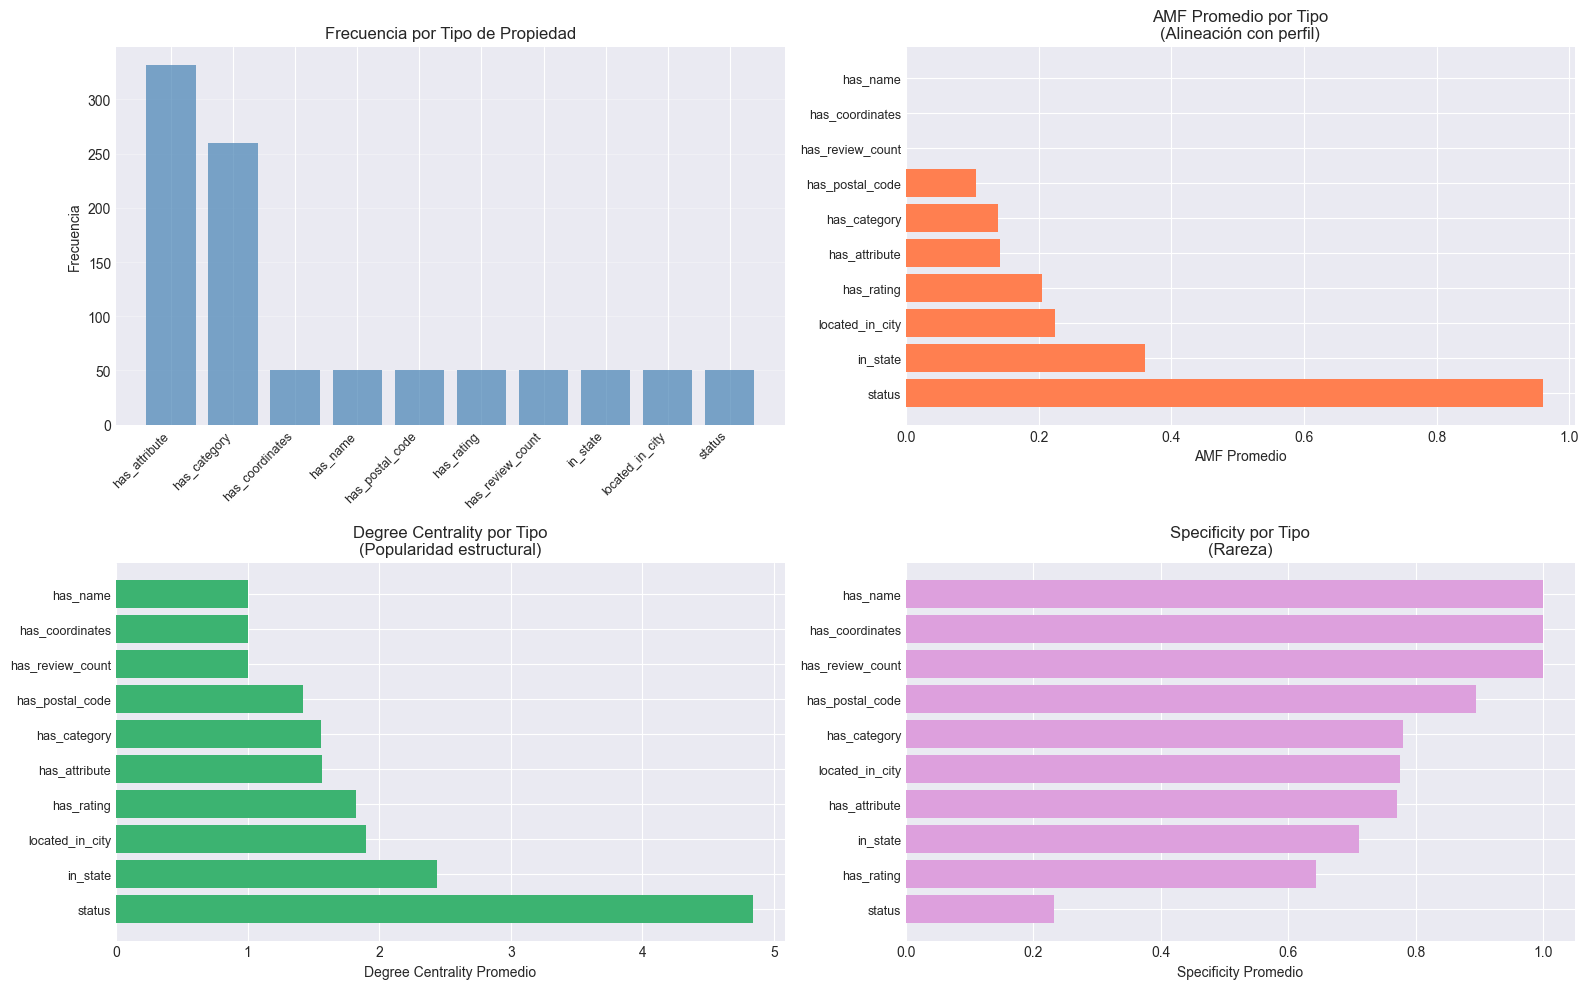

In [24]:
# %%
# 4.5 Distribución por tipo de propiedad
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Frecuencia por tipo
tipo_counts = df_propiedad['tipo_prop'].value_counts()
axes[0, 0].bar(range(len(tipo_counts)), tipo_counts.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xticks(range(len(tipo_counts)))
axes[0, 0].set_xticklabels(tipo_counts.index, rotation=45, ha='right', fontsize=9)
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Frecuencia por Tipo de Propiedad')
axes[0, 0].grid(axis='y', alpha=0.3)

# AMF promedio por tipo
amf_by_type = df_propiedad.groupby('tipo_prop')['amf'].mean().sort_values()
axes[0, 1].barh(range(len(amf_by_type)), amf_by_type.values, color='coral')
axes[0, 1].set_yticks(range(len(amf_by_type)))
axes[0, 1].set_yticklabels(amf_by_type.index, fontsize=9)
axes[0, 1].set_xlabel('AMF Promedio')
axes[0, 1].set_title('AMF Promedio por Tipo\n(Alineación con perfil)')
axes[0, 1].invert_yaxis()

# Degree Centrality promedio por tipo
degree_by_type = df_propiedad.groupby('tipo_prop')['degree_centrality'].mean().sort_values()
axes[1, 0].barh(range(len(degree_by_type)), degree_by_type.values, color='mediumseagreen')
axes[1, 0].set_yticks(range(len(degree_by_type)))
axes[1, 0].set_yticklabels(degree_by_type.index, fontsize=9)
axes[1, 0].set_xlabel('Degree Centrality Promedio')
axes[1, 0].set_title('Degree Centrality por Tipo\n(Popularidad estructural)')
axes[1, 0].invert_yaxis()

# Specificity promedio por tipo
spec_by_type = df_propiedad.groupby('tipo_prop')['attribute_specificity'].mean().sort_values(ascending=False)
axes[1, 1].barh(range(len(spec_by_type)), spec_by_type.values, color='plum')
axes[1, 1].set_yticks(range(len(spec_by_type)))
axes[1, 1].set_yticklabels(spec_by_type.index, fontsize=9)
axes[1, 1].set_xlabel('Specificity Promedio')
axes[1, 1].set_title('Specificity por Tipo\n(Rareza)')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('22_analisis_tipos_propiedad.png', dpi=300, bbox_inches='tight')
plt.show()

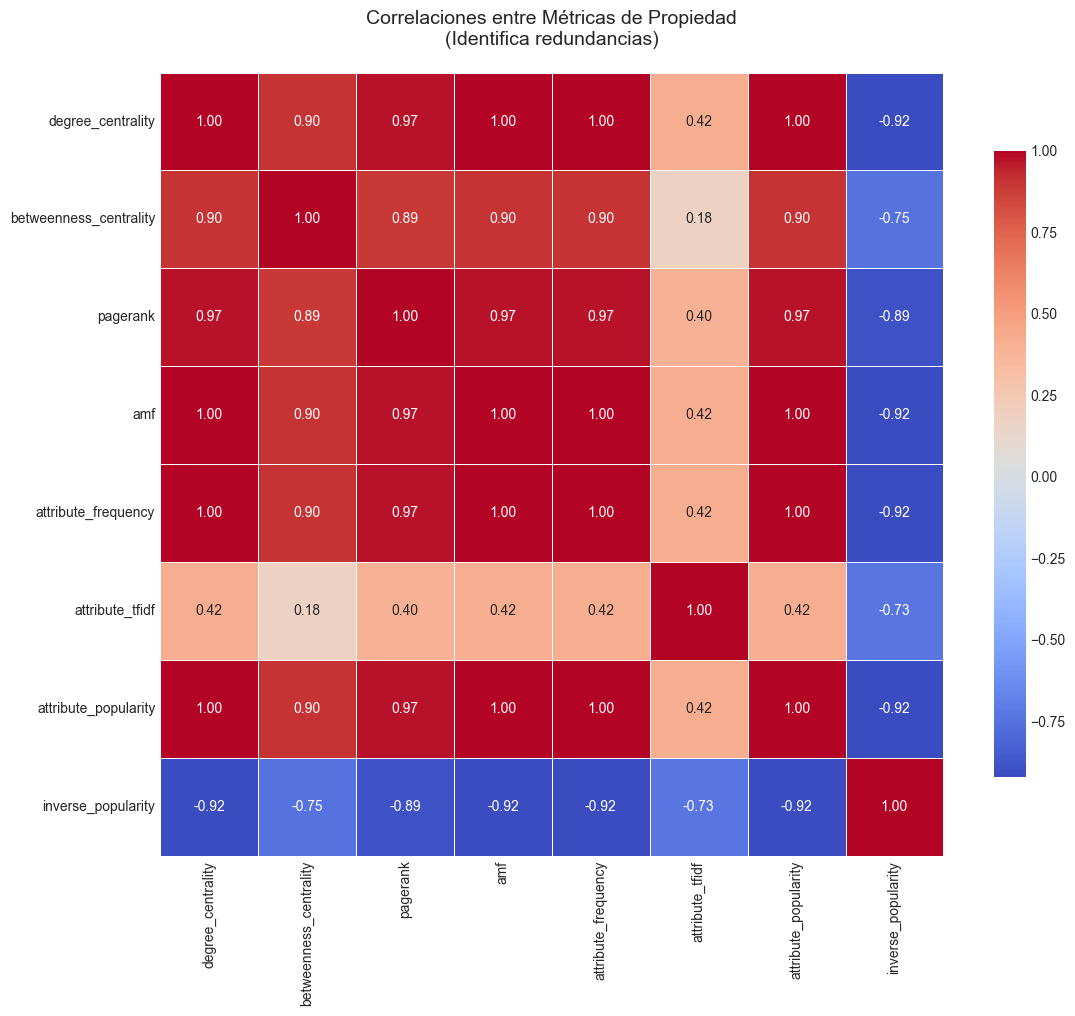

In [25]:
# %%
# 4.6 Heatmap de correlaciones entre métricas de propiedad
propiedad_metrics = ['degree_centrality', 'betweenness_centrality', 'pagerank', 
                     'amf', 'attribute_frequency', 'attribute_tfidf',
                     'attribute_popularity', 'inverse_popularity']

plt.figure(figsize=(12, 10))
corr_matrix = df_propiedad[propiedad_metrics].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlaciones entre Métricas de Propiedad\n(Identifica redundancias)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('23_correlaciones_propiedad.png', dpi=300, bbox_inches='tight')
plt.show()